# 04 – Regression: H1, H2 & H3

Dieses Notebook prüft:

- **H1**: `VADER Compound` (Sentiment) ~ `Age` + `Age²` (OLS)
- **H2**: `Rating` ~ `Age` + `Age²` (ordinal, `OrderedModel`), inkl. Test der Proportional-Odds-Annahme (Brant-Test + LR-Cross-Check)
- **H3**: Zusammenhang zwischen `VADER Compound` und `Rating`, ohne Alter oder weitere Kontrollvariablen, geprüft als `Rating ~ VADER Compound` (ordinal, `OrderedModel`, inkl. Proportional-Odds-Test), ergänzt um eine deskriptive Verteilungsanalyse sowie Pearson-/Spearman-Korrelation

Für H1 und H2 werden jeweils ein Basismodell, ein Hauptmodell mit Kontrollvariablen sowie Robustheitsprüfungen berechnet. `Positive Feedback Count` und `Recommended IND` werden aus den Hauptmodellen ausgeschlossen und nur im Rahmen separater Robustheitsprüfungen berücksichtigt. Der Grund dafür ist, dass beide Kennzahlen erst nach der Bewertung entstehen, entweder als Reaktion anderer Kundinnen und Kunden oder als Konsequenz der eigenen Bewertung. Im Sinne von Angrist und Pischke (2009) handelt es sich damit um sogenannte "bad controls", die zeitlich nach der zu erklärenden Grösse liegen und deren Einbezug die Schätzung verzerren könnte. H3 kommt ohne diese Kontrollvariablen aus, da hier ausschliesslich der direkte Zusammenhang zwischen den beiden Bewertungsmethoden von Interesse ist.


**Zentrierung von Age:** `Age` liegt in einem engen, ausschliesslich positiven Wertebereich von 18 bis 99 Jahren mit einem Mittelwert von etwa 43 Jahren. Dadurch sind `Age` und `Age²` stark korreliert, was sich in einer hohen Condition Number niederschlägt. Dies weist auf Multikollinearität hin, nicht auf eine strukturelle Fehlspezifikation des Modells. Alle Modelle werden daher mit der mittelwertzentrierten Altersvariable `Age_c = Age - mean(Age)` und deren Quadrat `Age_c²` geschätzt.

Dabei handelt es sich um eine reine Reparametrisierung. Da alle Modelle über einen freien Achsenabschnitt bei OLS beziehungsweise freie Schwellenwerte beim OrderedModel verfügen, kann die konstante Verschiebung vollständig aufgefangen werden. Die Modellanpassung (R², Pseudo R², AIC, Log Likelihood) bleibt dadurch exakt identisch. Lediglich die Koeffizienten, deren Standardfehler und die Condition Number verändern sich, was weiter unten numerisch bestätigt wird. Für H3 ist diese Zentrierung nicht relevant, da `Age` dort nicht als Prädiktor verwendet wird.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import chi2, pearsonr, spearmanr
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / "reviews_vader.csv")
df.shape

(22640, 18)

Die 22'640 Zeilen stimmen mit dem Endergebnis aus `03_VADER.ipynb` überein. Die 18 Spalten setzen sich aus den vorherigen 13 (aus dem `03_VADER.ipynb` Notebook) sowie 5 neuen Spalten zusammen: den 4 VADER-Werten (Negative, Neutral, Positive, Compound) und `VADER Sentiment` (die Klassenkategorie).

## Age zentrieren

Neben dem zentrierten Alter `Age_c` und dessen Quadrat `Age_c_sq` wird zur Veranschaulichung auch das unzentrierte `Age_sq` berechnet. Für die Modellschätzung werden jedoch ausschliesslich `Age_c` und `Age_c_sq` verwendet.

In [3]:
age_mean = df["Age"].mean()
df["Age_sq"] = df["Age"] ** 2
df["Age_c"] = df["Age"] - age_mean
df["Age_c_sq"] = df["Age_c"] ** 2

print(f"age_mean = {age_mean:.4f}")
df[["Age", "Age_sq", "Age_c", "Age_c_sq"]].describe()

age_mean = 43.2807


,Age,Age_sq,Age_c,Age_c_sq
count,22640.000000,22640.000000,2.264000e+04,22640.000000
mean,43.280654,2025.167668,-4.017203e-17,151.952682
std,12.327181,1161.464059,1.232718e+01,207.782487
min,18.000000,324.000000,-2.528065e+01,0.078767
25%,34.000000,1156.000000,-9.280654e+00,18.323996
50%,41.000000,1681.000000,-2.280654e+00,76.027000
75%,52.000000,2704.000000,8.719346e+00,203.937070
max,99.000000,9801.000000,5.571935e+01,3104.645551


Der Mittelwert von `Age_c` liegt bei praktisch 0 (-4.02e-17, eine numerisch bedingte Rundungsabweichung), was die korrekte Zentrierung bestätigt. Die ursprüngliche Variable `Age` weist weiterhin einen Wertebereich von 18 bis 99 Jahren auf.

Zur einheitlichen Auswertung der nachfolgenden Modelle werden drei Hilfsfunktionen definiert:
1. `params_table` fasst die Koeffizienten eines Modells übersichtlich zusammen
2. `turning_point` berechnet das geschätzte Minimum der U-förmigen Alterskurve und rechnet diesen auf die ursprüngliche Altersskala zurück.
3. `cond_number` quantifiziert die Multikollinearität einer Designmatrix.

In [4]:
def params_table(res, model_label):
    """Koeffizienten-Tabelle (Term/Koeffizient/SE/Statistik/p) eines Modells, mit Modelltyp-Spalte."""
    return pd.DataFrame({
        "Modelltyp": model_label,
        "Term": res.params.index,
        "Koeffizient": res.params.values,
        "SE": res.bse.values,
        "Statistik": res.tvalues.values,
        "p_Wert": res.pvalues.values,
    })


def turning_point(beta_age_c, beta_age_c_sq, mean_age=age_mean):
    """Geschätztes Minimum auf der echten Altersskala: zuerst in zentrierten Einheiten berechnen,
    dann den Mittelwert zurücktransformieren (-beta_age_c / (2*beta_age_c_sq) + mean_age)."""
    return -beta_age_c / (2 * beta_age_c_sq) + mean_age


def cond_number(X):
    """Condition Number einer Designmatrix (np.linalg.cond)."""
    return np.linalg.cond(np.asarray(X))

---

# H1: VADER Compound ~ Age + Age² (OLS)

1. **Basismodell**: nur `Age_c` + `Age_c²`
2. **Hauptmodell**: zusätzlich `Division Name`, `Department Name`
3. **Robustheitsmodell A**: Hauptmodell + `Recommended IND` (post-treatment-Variable, s. u.)
4. **Robustheitsmodell B**: Hauptmodell + `Positive Feedback Count` (post-treatment-Variable,
   s. u.)

`Recommended IND` wird, ebenso wie `Positive Feedback Count`, als "bad control" im Sinne von Angrist und Pischke (2009) behandelt. Die Entscheidung, ein Produkt weiterzuempfehlen, kann als Konsequenz der eigenen Bewertung betrachtet werden und liegt damit kausal nach den für die Analyse relevanten Bewertungsdimensionen Sentiment und Rating. Die Variable wird daher aus dem Hauptmodell ausgeschlossen und stattdessen nur in einem separaten Robustheitsmodell berücksichtigt.

`Class Name` wird weiterhin nicht aufgenommen, da es inhaltlich mit `Department Name` überlappt.


## Modell-Datensatz vorbereiten

In [5]:
h1_cols = {
    "VADER Compound": "vader_compound",
    "Age": "age",
    "Age_sq": "age_sq",
    "Age_c": "age_c",
    "Age_c_sq": "age_c_sq",
    "Division Name": "division_name",
    "Department Name": "department_name",
    "Recommended IND": "recommended_ind",
    "Positive Feedback Count": "positive_feedback_count",
}

h1_df = df[list(h1_cols.keys())].rename(columns=h1_cols)
h1_df.isna().sum()

vader_compound              0
age                         0
age_sq                      0
age_c                       0
age_c_sq                    0
division_name              13
department_name            13
recommended_ind             0
positive_feedback_count     0
dtype: int64

Die 13 Zeilen mit fehlenden Werten bei `Division Name` beziehungsweise `Department Name` werden von `statsmodels` im Hauptmodell und in den beiden Robustheitsmodellen automatisch listenweise ausgeschlossen. Das Basismodell, das ausschliesslich die Altersvariablen enthält, nutzt hingegen alle 22'640 Beobachtungen.

Zu jedem Modell wird zusätzlich die **unzentrierte** Variante geschätzt. Sie dient ausschliesslich dem Vergleich der Condition Number und bestätigt, dass die Modellgüte durch die Zentrierung unverändert bleibt. Gespeichert und berichtet wird abschliessend nur die zentrierte Variante.

## Basismodell: Age + Age²

In [6]:
h1_basis_raw = smf.ols("vader_compound ~ age + age_sq", data=h1_df).fit()
h1_basis = smf.ols("vader_compound ~ age_c + age_c_sq", data=h1_df).fit()
print(h1_basis.summary())

                            OLS Regression Results                            
Dep. Variable:         vader_compound   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.336
Date:                Wed, 09 Sep 2026   Prob (F-statistic):             0.0131
Time:                        13:09:02   Log-Likelihood:                -9410.2
No. Observations:               22640   AIC:                         1.883e+04
Df Residuals:                   22637   BIC:                         1.885e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7349      0.003    236.664      0.0

Das Basismodell erklärt praktisch keine Varianz (R² ≈ 0,000), ist jedoch als Gesamtmodell statistisch signifikant (p = 0,0131). Der lineare Term `age_c` ist nicht statistisch signifikant (p = 0,160), während der quadratische Term `age_c_sq` statistische Signifikanz aufweist (p = 0,003). Dies liefert einen ersten Hinweis auf einen nicht linearen Zusammenhang zwischen Alter und Sentiment, wobei die erklärte Varianz insgesamt sehr gering ist. Die Condition Number von 328 ist im Vergleich zur unzentrierten Modellspezifikation deutlich reduziert.


## Hauptmodell: + Division Name, Department Name

`Recommended IND` wird hier bewusst nicht aufgenommen (siehe Begründung oben sowie
Robustheitsmodell A weiter unten).


In [7]:
h1_haupt_raw = smf.ols(
    "vader_compound ~ age + age_sq + C(division_name) + C(department_name)",
    data=h1_df,
).fit()
h1_haupt = smf.ols(
    "vader_compound ~ age_c + age_c_sq + C(division_name) + C(department_name)",
    data=h1_df,
).fit()
print(h1_haupt.summary())


                            OLS Regression Results                            
Dep. Variable:         vader_compound   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.887
Date:                Wed, 09 Sep 2026   Prob (F-statistic):            0.00206
Time:                        13:09:02   Log-Likelihood:                -9400.4
No. Observations:               22627   AIC:                         1.882e+04
Df Residuals:                   22617   BIC:                         1.890e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

Ohne `Recommended IND` erklärt das Hauptmodell nur noch einen sehr geringen Anteil der Varianz (R² = 0,0011 gegenüber R² = 0,1920 bei Einbezug von `Recommended IND` (siehe Robustheitsmodell A weiter unten)). Dies zeigt, dass ein grosser Teil der zusätzlichen Erklärungskraft des erweiterten Modells mit dieser Post Treatment Variable verbunden ist. Der lineare Alterseffekt `age_c` ist nicht statistisch signifikant (p = 0,141), während der quadratische Term `age_c_sq` weiterhin statistische Signifikanz aufweist (p = 0,003). Damit bestehen weiterhin Hinweise auf einen U-förmigen, nicht linearen Zusammenhang zwischen Alter und Sentiment. Dieser Zusammenhang ist jedoch insgesamt schwach und wird primär durch den quadratischen Term getragen. Unter den Produktkategorien bleibt `Department Name` = Trend statistisch signifikant (p < 0,001).


Die von `statsmodels` ausgegebene Warnung zur hohen Condition Number (siehe unter Notes [2]) ist nach der Zentrierung der Altersvariable nicht mehr primär auf die gemeinsame Verwendung von `Age` und `Age²` zurückzuführen. Sie dürfte vielmehr mit der Struktur und Skalierung der übrigen Prädiktoren, insbesondere den zahlreichen Dummy Variablen der Kategorievariablen, zusammenhängen (siehe Zentrierungserklärung oben).

## Robustheitsmodell A: Hauptmodell + Recommended IND

"Bad control" Problematik (Angrist und Pischke, 2009): Die Entscheidung einer Person, ein Produkt weiterzuempfehlen (`Recommended IND`), kann als Konsequenz ihrer Bewertung betrachtet werden und ist damit dem gemessenen Sentiment (`VADER Compound`) kausal nachgelagert, anstatt dessen Ursache zu sein. Die Kontrolle für eine solche Post Treatment Variable im Hauptmodell könnte den geschätzten Alterseffekt verzerren. `Recommended IND` wird daher nicht in das Hauptmodell aufgenommen, sondern nur im Rahmen einer Robustheitsprüfung berücksichtigt.

In [8]:
h1_robust_a_raw = smf.ols(
    "vader_compound ~ age + age_sq + C(division_name) + C(department_name) + recommended_ind",
    data=h1_df,
).fit()
h1_robust_a = smf.ols(
    "vader_compound ~ age_c + age_c_sq + C(division_name) + C(department_name) + recommended_ind",
    data=h1_df,
).fit()
print(h1_robust_a.summary())


                            OLS Regression Results                            
Dep. Variable:         vader_compound   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     537.5
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:09:02   Log-Likelihood:                -7001.0
No. Observations:               22627   AIC:                         1.402e+04
Df Residuals:                   22616   BIC:                         1.411e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

Die Aufnahme von `Recommended IND` verändert die Modellergebnisse deutlich: R² steigt von 0,0011 im Hauptmodell auf 0,1920. `Recommended IND` weist dabei einen positiven und statistisch signifikanten Koeffizienten von 0,4168 auf (p < 0,001) und ist mit einem erheblichen Anstieg der erklärten Varianz verbunden. Zugleich wird `age_c` durch die Aufnahme von `Recommended IND` statistisch signifikant (p < 0,001), und das geschätzte Minimum verschiebt sich auf 57,13 Jahre (siehe Vergleich der geschätzten Minima weiter unten). Dieses Muster ist mit der eingangs beschriebenen "bad control" Problematik vereinbar: `Recommended IND` wird als dem Sentiment kausal nachgelagerte Variable betrachtet, deren Aufnahme die Schätzung des Alterseffekts spürbar verändert. Die Variable wird daher bewusst nicht im Hauptmodell, sondern nur im Rahmen dieser Robustheitsprüfung berücksichtigt.


## Robustheitsmodell B: Hauptmodell + Positive Feedback Count

"Bad control" Problematik (Angrist und Pischke, 2009): `Positive Feedback Count` gibt an, wie viele andere Personen eine Review nachträglich als hilfreich markiert haben. Dieser Wert entsteht somit zeitlich nach der Review und damit nach dem gemessenen Sentiment. Zudem kann er selbst vom Sentiment beziehungsweise vom Inhalt der Review beeinflusst sein. Die Kontrolle für eine solche Post Treatment Variable im Hauptmodell könnte den geschätzten Alterseffekt verzerren. `Positive Feedback Count` wird daher nicht in das Hauptmodell aufgenommen, sondern analog zu `Recommended IND` nur im Rahmen einer separaten Robustheitsprüfung berücksichtigt.

In [9]:
h1_robust_b_raw = smf.ols(
    "vader_compound ~ age + age_sq + C(division_name) + C(department_name)"
    " + positive_feedback_count",
    data=h1_df,
).fit()
h1_robust_b = smf.ols(
    "vader_compound ~ age_c + age_c_sq + C(division_name) + C(department_name)"
    " + positive_feedback_count",
    data=h1_df,
).fit()
print(h1_robust_b.summary())


                            OLS Regression Results                            
Dep. Variable:         vader_compound   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.738
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           4.91e-05
Time:                        13:09:02   Log-Likelihood:                -9394.7
No. Observations:               22627   AIC:                         1.881e+04
Df Residuals:                   22616   BIC:                         1.890e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

Die Aufnahme von `Positive Feedback Count` verändert die Modellgüte kaum. R² steigt lediglich von 0,001 auf 0,002, während das geschätzte Minimum mit 47,06 Jahren nahe am Wert des Hauptmodells von 47,42 Jahren liegt. `Positive Feedback Count` weist zwar einen statistisch signifikanten negativen Koeffizienten auf (Koeffizient = −0,0014, p = 0,001), verändert die Ergebnisse für die Altersvariablen jedoch kaum. `age_c` bleibt weiterhin statistisch nicht signifikant (p = 0,189), während `age_c_sq` statistisch signifikant bleibt (p = 0,003). Die geringe Veränderung der Modellgüte und des geschätzten Minimums zeigt, dass die zentralen Ergebnisse des Hauptmodells gegenüber der zusätzlichen Aufnahme von `Positive Feedback Count` weitgehend robust sind. Unabhängig davon wird die Variable aufgrund ihrer Einordnung als Post Treatment Variable nicht in das Hauptmodell aufgenommen.

## Condition Number vorher/nachher & Bestätigung gleicher Modellgüte

In [10]:
h1_model_pairs = {
    "Basismodell": (h1_basis_raw, h1_basis),
    "Hauptmodell": (h1_haupt_raw, h1_haupt),
    "Robustheitsmodell A (+ Recommended IND)": (h1_robust_a_raw, h1_robust_a),
    "Robustheitsmodell B (+ Positive Feedback Count)": (h1_robust_b_raw, h1_robust_b),
}

h1_cond_check = pd.DataFrame([
    {
        "Modelltyp": label,
        "Cond_No_roh": cond_number(raw.model.exog),
        "Cond_No_zentriert": cond_number(centered.model.exog),
        "R2_roh": raw.rsquared,
        "R2_zentriert": centered.rsquared,
        "AIC_roh": raw.aic,
        "AIC_zentriert": centered.aic,
        "max_abs_diff_R2_AIC": max(abs(raw.rsquared - centered.rsquared), abs(raw.aic - centered.aic)),
    }
    for label, (raw, centered) in h1_model_pairs.items()
])
h1_cond_check


,Modelltyp,Cond_No_roh,Cond_No_zentriert,R2_roh,R2_zentriert,AIC_roh,AIC_zentriert,max_abs_diff_R2_AIC
0,Basismodell,25703.825235,328.065154,0.000383,0.000383,18826.487834,18826.487834,2.220446e-16
1,Hauptmodell,34517.569759,3805.412896,0.001148,0.001148,18820.860405,18820.860405,7.275958e-12
2,Robustheitsmodell A (+ Recommended IND),34521.941747,3805.706567,0.192036,0.192036,14023.919467,14023.919467,0.000000e+00
3,Robustheitsmodell B (+ Positive Feedback Count),34519.629762,3805.685120,0.001650,0.001650,18811.474115,18811.474115,7.275958e-12


Die Tabelle bestätigt die eingangs beschriebene Reparametrisierung: R² und AIC sind zwischen der unzentrierten und der zentrierten Variante in allen vier Modellen identisch. Die maximale Abweichung liegt lediglich im Bereich numerischer Rechenungenauigkeit. Die Condition Number sinkt durch die Zentrierung hingegen deutlich, was insbesondere die numerische Multikollinearität zwischen dem linearen und dem quadratischen Altersterm reduziert.


## Modellvergleich (R², AIC)

In [11]:
h1_comparison = summary_col(
    [h1_basis, h1_haupt, h1_robust_a, h1_robust_b],
    model_names=["Basismodell", "Hauptmodell", "Robustheitsmodell A (+Recommended IND)", "Robustheitsmodell B (+PFC)"],
    stars=True,
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.4f}",
        "Adj. R2": lambda x: f"{x.rsquared_adj:4f}",
        "AIC": lambda x: f"{x.aic:.1f}",
        "BIC": lambda x: f"{x.bic:.1f}",
    },
)
print(h1_comparison)



                                   Basismodell Hauptmodell Robustheitsmodell A (+Recommended IND) Robustheitsmodell B (+PFC)
----------------------------------------------------------------------------------------------------------------------------
Intercept                          0.7349***   0.7434***   0.3924***                              0.7466***                 
                                   (0.0031)    (0.0066)    (0.0076)                               (0.0066)                  
age_c                              -0.0003     -0.0003     -0.0007***                             -0.0003                   
                                   (0.0002)    (0.0002)    (0.0002)                               (0.0002)                  
age_c_sq                           0.0000***   0.0000***   0.0000**                               0.0000***                 
                                   (0.0000)    (0.0000)    (0.0000)                               (0.0000)                  

Die Modellübersicht zeigt ein differenziertes Bild: Der quadratische Term `age_c_sq` ist über alle vier Modellspezifikationen hinweg statistisch signifikant, sodass sich durchgängig Hinweise auf eine Krümmung des Zusammenhangs zwischen Alter und Sentiment zeigen. Der lineare Term `age_c` ist dagegen nur in Robustheitsmodell A mit `Recommended IND` statistisch signifikant. Im Hauptmodell und in Robustheitsmodell B ist er nicht statistisch signifikant (p = 0,141 beziehungsweise p = 0,189). Die fehlende Signifikanz des linearen Terms schliesst eine U-förmige Beziehung jedoch nicht grundsätzlich aus. Für deren Beurteilung sind insbesondere das Vorzeichen und die Signifikanz des quadratischen Terms sowie die Lage des geschätzten Minimums innerhalb des beobachteten Altersbereichs relevant. Insgesamt ist der Zusammenhang schwach ausgeprägt und sollte entsprechend vorsichtig interpretiert werden. Die deutlichste Verbesserung der Modellgüte zeigt sich bei der Aufnahme von `Recommended IND` in Robustheitsmodell A, während die Kontrollvariablen des Hauptmodells und `Positive Feedback Count` nur einen geringen zusätzlichen Beitrag zur erklärten Varianz leisten.

In [12]:
h1_fit_stats = pd.DataFrame({
    "Basismodell": [h1_basis.nobs, h1_basis.rsquared, h1_basis.rsquared_adj, h1_basis.aic, h1_basis.bic],
    "Hauptmodell": [h1_haupt.nobs, h1_haupt.rsquared, h1_haupt.rsquared_adj, h1_haupt.aic, h1_haupt.bic],
    "Robustheitsmodell A (+Recommended IND)": [h1_robust_a.nobs, h1_robust_a.rsquared, h1_robust_a.rsquared_adj, h1_robust_a.aic, h1_robust_a.bic],
    "Robustheitsmodell B (+PFC)": [h1_robust_b.nobs, h1_robust_b.rsquared, h1_robust_b.rsquared_adj, h1_robust_b.aic, h1_robust_b.bic],
}, index=["N", "R2", "Adj. R2", "AIC", "BIC"])
h1_fit_stats


,Basismodell,Hauptmodell,Robustheitsmodell A (+Recommended IND),Robustheitsmodell B (+PFC)
N,22640.000000,22627.000000,22627.000000,22627.000000
R2,0.000383,0.001148,0.192036,0.001650
Adj. R2,0.000295,0.000750,0.191679,0.001209
AIC,18826.487834,18820.860405,14023.919467,18811.474115
BIC,18850.570254,18901.129396,14112.215358,18899.770006


Die Beobachtungszahl sinkt von 22'640 im Basismodell auf 22'627 im Hauptmodell und in beiden Robustheitsmodellen, was den 13 Zeilen (welche in Schritt 3 der Datenbereinigung dokumentiert wurden) mit fehlender Produktkategorie entspricht.


## Ergebnistabelle & Speichern

Abschliessend werden alle Koeffizienten sowie die zentralen Modellkennzahlen (geschätztes Minimum, R², AIC und Condition Number) der vier H1 Modelle in einer gemeinsamen Tabelle zusammengeführt und unter `results/h1_regression_updated.csv` gespeichert. Zusätzlich werden die vollständigen Modellzusammenfassungen sowie eine kompakte Übersicht der Gütemasse in separaten Dateien abgelegt.

In [13]:
h1_models = {
    "Basismodell": h1_basis,
    "Hauptmodell": h1_haupt,
    "Robustheitsmodell A (+ Recommended IND)": h1_robust_a,
    "Robustheitsmodell B (+ Positive Feedback Count)": h1_robust_b,
}

h1_coef_rows = pd.concat(
    [params_table(res, label) for label, res in h1_models.items()],
    ignore_index=True,
)

h1_summary_rows = []
for label, res in h1_models.items():
    tp = turning_point(res.params["age_c"], res.params["age_c_sq"])
    cond_raw = h1_cond_check.loc[h1_cond_check["Modelltyp"] == label, "Cond_No_roh"].iloc[0]
    cond_c = h1_cond_check.loc[h1_cond_check["Modelltyp"] == label, "Cond_No_zentriert"].iloc[0]
    for term, value in [
        ("Geschätztes Minimum (Age)", tp),
        ("R2", res.rsquared),
        ("Adj. R2", res.rsquared_adj),
        ("AIC", res.aic),
        ("N", res.nobs),
        ("Condition Number (roh)", cond_raw),
        ("Condition Number (zentriert)", cond_c),
    ]:
        h1_summary_rows.append({"Modelltyp": label, "Term": term, "Koeffizient": value})

h1_results_updated = pd.concat([h1_coef_rows, pd.DataFrame(h1_summary_rows)], ignore_index=True)
h1_results_updated.to_csv(RESULTS_DIR / "h1_regression_updated.csv", index=False)
h1_results_updated


,Modelltyp,Term,Koeffizient,SE,Statistik,p_Wert
0,Basismodell,Intercept,0.734893,0.003105,236.664140,0.000000
1,Basismodell,age_c,-0.000300,0.000213,-1.406618,0.159555
2,Basismodell,age_c_sq,0.000037,0.000013,2.926743,0.003429
3,Hauptmodell,Intercept,0.743390,0.006558,113.358002,0.000000
4,Hauptmodell,C(division_name)[T.General Petite],0.007540,0.005279,1.428240,0.153237
...,...,...,...,...,...,...
58,Robustheitsmodell B (+ Positive Feedback Count),Adj. R2,0.001209,NaN,NaN,NaN
59,Robustheitsmodell B (+ Positive Feedback Count),AIC,18811.474115,NaN,NaN,NaN
60,Robustheitsmodell B (+ Positive Feedback Count),N,22627.000000,NaN,NaN,NaN
61,Robustheitsmodell B (+ Positive Feedback Count),Condition Number (roh),34519.629762,NaN,NaN,NaN


Die Tabelle liegt im langen Format vor. Neben den Koeffizienten mit Standardfehler, Teststatistik und p-Wert enthält sie auch zusammenfassende Modellkennzahlen wie das geschätzte Minimum, R² und die Condition Number. Für diese Kennzahlen bleiben die zusätzlichen Spalten für Standardfehler, Teststatistik und p-Wert naturgemäss leer (`NaN`).

Abschliessend werden die vollständigen Regressionsprotokolle aller vier Modelle sowie der zusammenfassende Modellvergleich als Textdateien im Ordner `results` abgelegt. Die Gütemasse werden zusätzlich als CSV Datei gespeichert. Diese Dateien dienen als Nachweis der vollständigen Modellergebnisse und als Grundlage für die Ergebnisdarstellung in Kapitel 4.

In [14]:
with open(RESULTS_DIR / "h1_regression_basismodell.txt", "w") as f:
    f.write(h1_basis.summary().as_text())
with open(RESULTS_DIR / "h1_regression_hauptmodell.txt", "w") as f:
    f.write(h1_haupt.summary().as_text())
with open(RESULTS_DIR / "h1_regression_robustheitsmodell_a.txt", "w") as f:
    f.write(h1_robust_a.summary().as_text())
with open(RESULTS_DIR / "h1_regression_robustheitsmodell_b.txt", "w") as f:
    f.write(h1_robust_b.summary().as_text())
with open(RESULTS_DIR / "h1_regression_vergleich.txt", "w") as f:
    f.write(h1_comparison.as_text())
h1_fit_stats.to_csv(RESULTS_DIR / "h1_regression_fit_stats.csv")

sorted(p.name for p in RESULTS_DIR.glob("h1_*"))


['h1_h2_kategorien_robustheit_class.csv',
 'h1_h2_kategorien_robustheit_department.csv',
 'h1_h2_kategorien_robustheit_division.csv',
 'h1_h2_turning_point_bootstrap.csv',
 'h1_regression_basismodell.txt',
 'h1_regression_fit_stats.csv',
 'h1_regression_hauptmodell.txt',
 'h1_regression_robustheitsmodell_a.txt',
 'h1_regression_robustheitsmodell_b.txt',
 'h1_regression_updated.csv',
 'h1_regression_vergleich.txt',
 'h1_residual_diagnostics.csv']

## Visualisierung: Alterseffekt auf Sentiment (H1)

Ergänzend zu den Koeffiziententabellen wird der im H1 Hauptmodell geschätzte Alterseffekt grafisch dargestellt. Die Abbildung zeigt die beobachteten Mittelwerte von `VADER Compound` je 5 Jahres Altersgruppe mit 95 Prozent Konfidenzintervallen auf Basis der t-Verteilung sowie die vom Hauptmodell vorhergesagte Kurve. Die Kurve wird für die Referenzkategorien ausgewertet (`Division Name` = General, `Department Name` = Bottoms, siehe Hinweis zur Dummy Kodierung bei H2). Da alle Dummy Koeffizienten für diese Referenzkategorien den Wert null annehmen, wird die Vorhersage ausschliesslich durch den Intercept sowie `age_c` und `age_c_sq` bestimmt.

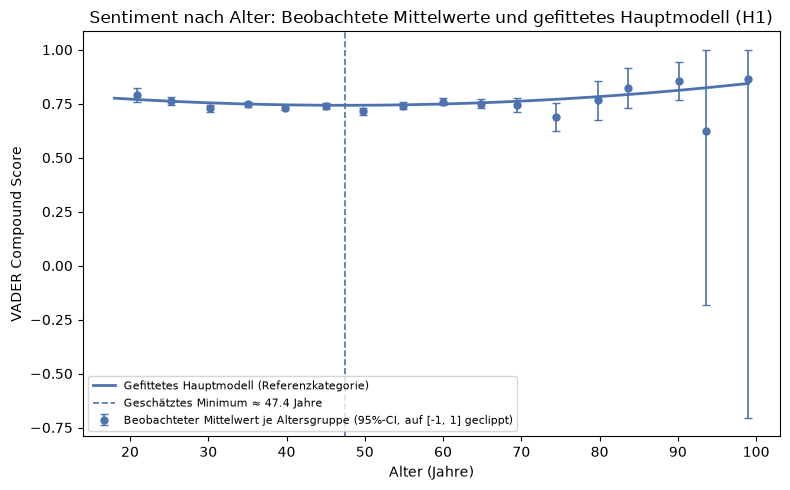

Geschätztes Minimum H1-Hauptmodell (für Grafik verwendet): 47.42 Jahre


,Altersgruppe,compound_mean,compound_std,n,age_mean_obs,sem,ci95,ci_lower,ci_upper
0,18-22,0.789053,0.327205,387,20.852713,0.016633,0.032702,0.756351,0.821755
1,23-27,0.763254,0.347913,1543,25.225535,0.008857,0.017373,0.745881,0.780627
2,28-32,0.728048,0.378761,2434,30.173377,0.007677,0.015055,0.712994,0.743103
3,33-37,0.747637,0.359554,3843,35.023159,0.005800,0.011371,0.736266,0.759009
4,38-42,0.732338,0.372986,3903,39.805022,0.005970,0.011705,0.720633,0.744043
5,43-47,0.739028,0.359751,2898,45.025880,0.006683,0.013103,0.725924,0.752131
6,48-52,0.715883,0.391306,2270,49.798678,0.008213,0.016106,0.699777,0.731989
7,53-57,0.740567,0.362937,2053,54.853385,0.008010,0.015709,0.724858,0.756276
8,58-62,0.759918,0.346540,1478,60.014885,0.009014,0.017682,0.742237,0.777600
9,63-67,0.750143,0.374268,1121,64.886708,0.011178,0.021933,0.728210,0.772076


In [15]:
from scipy.stats import t as t_dist

# 5-Jahres-Altersgruppen: 18-22, 23-27, ..., 93-97, 98-99 (letzte Gruppe kürzer, da Age nur bis 99 reicht)
h1_age_bin_edges = list(range(18, 99, 5)) + [100]
h1_age_bin_labels = [f"{h1_age_bin_edges[i]}-{h1_age_bin_edges[i + 1] - 1}" for i in range(len(h1_age_bin_edges) - 1)]
h1_age_groups = pd.cut(df["Age"], bins=h1_age_bin_edges, right=False, labels=h1_age_bin_labels)

h1_group_stats = df.groupby(h1_age_groups, observed=True)["VADER Compound"].agg(["mean", "std", "size"]).reset_index()
h1_group_stats.columns = ["Altersgruppe", "compound_mean", "compound_std", "n"]
h1_group_stats["age_mean_obs"] = df.groupby(h1_age_groups, observed=True)["Age"].mean().values
h1_group_stats["sem"] = h1_group_stats["compound_std"] / np.sqrt(h1_group_stats["n"])
h1_group_stats["ci95"] = h1_group_stats["sem"] * t_dist.ppf(0.975, h1_group_stats["n"] - 1)

# CI-Grenzen auf den gültigen Wertebereich von VADER Compound [-1, 1] clippen (nur die Fehlerbalken,
# nicht der Punktschätzer selbst, der ohnehin stets im gültigen Bereich liegt). Bei kleinen
# Altersgruppen (v.a. am oberen Altersrand) reicht das unclippte CI sonst ausserhalb dieses Bereichs.
h1_group_stats["ci_lower"] = (h1_group_stats["compound_mean"] - h1_group_stats["ci95"]).clip(lower=-1.0, upper=1.0)
h1_group_stats["ci_upper"] = (h1_group_stats["compound_mean"] + h1_group_stats["ci95"]).clip(lower=-1.0, upper=1.0)
h1_yerr = np.vstack([
    h1_group_stats["compound_mean"] - h1_group_stats["ci_lower"],
    h1_group_stats["ci_upper"] - h1_group_stats["compound_mean"],
])

# Gefittete Kurve des H1-Hauptmodells an der Referenzkategorie (alle Dummy-Koeffizienten = 0):
# vader_compound_hat = Intercept + beta_age_c * age_c + beta_age_c_sq * age_c_sq
h1_age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 300)
h1_age_c_grid = h1_age_grid - age_mean
h1_fitted_curve = (
    h1_haupt.params["Intercept"]
    + h1_haupt.params["age_c"] * h1_age_c_grid
    + h1_haupt.params["age_c_sq"] * h1_age_c_grid ** 2
)
tp_h1_haupt = turning_point(h1_haupt.params["age_c"], h1_haupt.params["age_c_sq"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    h1_group_stats["age_mean_obs"], h1_group_stats["compound_mean"], yerr=h1_yerr,
    fmt="o", color="#4C72B0", ecolor="#4C72B0", elinewidth=1.2, capsize=3, markersize=5,
    label="Beobachteter Mittelwert je Altersgruppe (95%-CI, auf [-1, 1] geclippt)",
)
ax.plot(h1_age_grid, h1_fitted_curve, color="#4C72B0", linewidth=2,
        label="Gefittetes Hauptmodell (Referenzkategorie)")
ax.axvline(tp_h1_haupt, color="#4C72B0", linestyle="--", linewidth=1.2,
           label=f"Geschätztes Minimum \u2248 {tp_h1_haupt:.1f} Jahre")
ax.set_xlabel("Alter (Jahre)")
ax.set_ylabel("VADER Compound Score")
ax.set_title("Sentiment nach Alter: Beobachtete Mittelwerte und gefittetes Hauptmodell (H1)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "h1_age_fitted_curve.png", dpi=150)
plt.show()

print(f"Geschätztes Minimum H1-Hauptmodell (für Grafik verwendet): {tp_h1_haupt:.2f} Jahre")
h1_group_stats

Die breiten Konfidenzintervalle bei sehr hohem Alter ab etwa 85 Jahren spiegeln die geringe Fallzahl in diesen Altersgruppen wider und relativieren die Aussagekraft der Kurve am rechten Rand.

## Residualdiagnostik (H1)

Geprüft werden die im Methodikteil beschriebenen OLS Annahmen für das Hauptmodell und ergänzend für das Basismodell: Linearität, Homoskedastizität und Normalverteilung der Residuen sowie die Gesamtsignifikanz des Modells mittels F Test.

### Linearität & Homoskedastizität: Residuen vs. Fitted

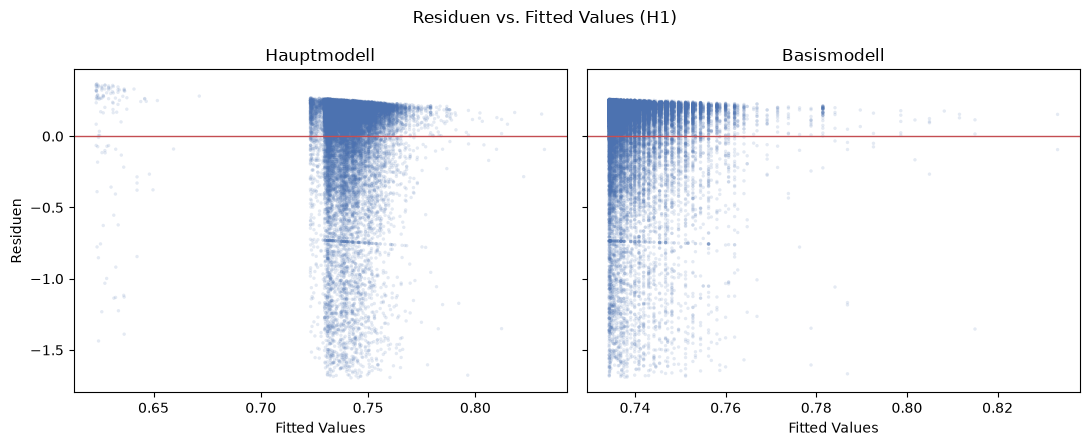

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, (label, res) in zip(axes, [("Hauptmodell", h1_haupt), ("Basismodell", h1_basis)]):
    fitted = res.fittedvalues
    resid = res.resid
    ax.scatter(fitted, resid, s=6, alpha=0.15, color="#4C72B0", edgecolor="none")
    ax.axhline(0, color="#C44E52", linewidth=1)
    ax.set_xlabel("Fitted Values")
    ax.set_title(label)

axes[0].set_ylabel("Residuen")
fig.suptitle("Residuen vs. Fitted Values (H1)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "h1_residuals_vs_fitted.png", dpi=150)
plt.show()

Bei der visuellen Beurteilung gilt: Zeigt der Plot der Residuen gegen die vorhergesagten Werte kein systematisches oder erkennbares Muster, beispielsweise eine ausgeprägte Bogenform, spricht dies dafür, dass die funktionale Form des Modells angemessen spezifiziert ist. Nimmt die Streuung der Residuen dagegen mit steigenden Fitted Values sichtbar zu oder ab, beispielsweise in Form einer trichterförmigen Verteilung, deutet dies auf Heteroskedastizität hin. In diesem Fall ist die Varianz der Fehler nicht über den gesamten Wertebereich hinweg konstant. Ob tatsächlich Heteroskedastizität vorliegt, wird anschliessend formal mit dem Breusch Pagan Test geprüft.

Aufgrund der überwiegend kategorialen Kontrollvariablen (`Division Name` und `Department Name`) entstehen im Plot mehrere senkrechte Punktbänder anstelle einer gleichmässig verteilten Punktwolke. Jedes Band entspricht einer Kombination dieser Kategorien mit dem jeweiligen Alter. Eine ausgeprägte Bogenform, die auf eine unzureichende funktionale Spezifikation hindeuten könnte, ist nicht erkennbar. Auch eine eindeutige trichterförmige Streuung zeigt sich nicht. Ob dennoch Hinweise auf Heteroskedastizität vorliegen, wird daher ergänzend mit dem Breusch Pagan Test formal geprüft.

In [17]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import skew, kurtosis
from statsmodels.graphics.gofplots import qqplot

bp_results = {}
for label, res in [("Hauptmodell", h1_haupt), ("Basismodell", h1_basis)]:
    bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(res.resid, res.model.exog)
    bp_results[label] = {"bp_stat": bp_stat, "bp_pvalue": bp_pvalue, "bp_fstat": bp_fstat, "bp_fpvalue": bp_fpvalue}

pd.DataFrame(bp_results).T

,bp_stat,bp_pvalue,bp_fstat,bp_fpvalue
Hauptmodell,13.212369,0.153230,1.468249,0.153227
Basismodell,0.678533,0.712293,0.339232,0.712321


Weder für das Hauptmodell (BP p = 0,153) noch für das Basismodell (BP p = 0,712) ergeben sich statistisch signifikante Hinweise auf Heteroskedastizität. Dies unterscheidet sich deutlich vom früheren Modell mit `Recommended IND`, für das der Breusch Pagan Test ein statistisch signifikantes Ergebnis zeigte. Der Vergleich deutet darauf hin, dass die Aufnahme von `Recommended IND` mit der dort festgestellten Heteroskedastizität zusammenhängt. Eine eindeutige kausale Zuordnung der Heteroskedastizität zu dieser Variable ist auf Basis des Modellvergleichs jedoch nicht möglich.

### Normalverteilung der Residuen: Q-Q-Plot, Jarque-Bera, Skewness und Kurtosis

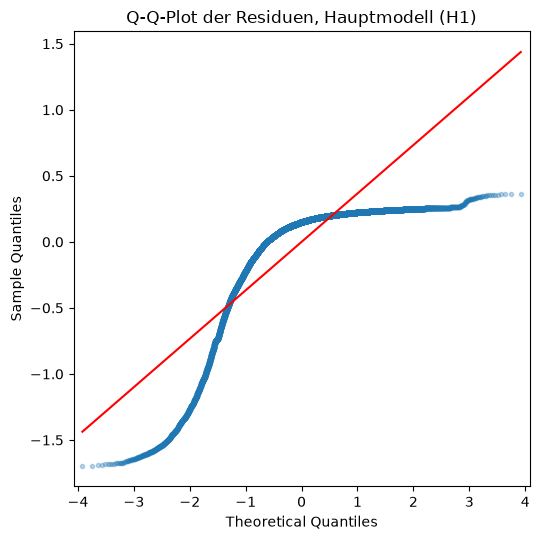

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
qqplot(h1_haupt.resid, line="s", ax=ax, markersize=3, alpha=0.3)
ax.set_title("Q-Q-Plot der Residuen, Hauptmodell (H1)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "h1_qqplot_hauptmodell.png", dpi=150)
plt.show()

In [19]:
normality_results = {}
for label, res in [("Hauptmodell", h1_haupt), ("Basismodell", h1_basis)]:
    jb_stat, jb_pvalue, jb_skew, jb_kurtosis = jarque_bera(res.resid)
    normality_results[label] = {
        "jb_stat": jb_stat,
        "jb_pvalue": jb_pvalue,
        "skewness": skew(res.resid),
        "kurtosis_excess": kurtosis(res.resid),  # Fisher-Definition: 0 = Normalverteilung
    }

pd.DataFrame(normality_results).T

,jb_stat,jb_pvalue,skewness,kurtosis_excess
Hauptmodell,53263.993957,0.0,-2.427398,5.738204
Basismodell,53398.271925,0.0,-2.429728,5.743834


Die Kennzahlen bestätigen quantitativ die im Q-Q-Plot erkennbare Abweichung von der Normalverteilung. Eine Skewness von rund −2,4, die im Hauptmodell und Basismodell nahezu identisch ausfällt, weist auf eine deutlich linksschiefe Residuenverteilung mit einem ausgeprägten linken Verteilungsschwanz hin. Die Exzess Kurtosis von rund 5,7 liegt deutlich über dem Wert von 0, der für eine Normalverteilung zu erwarten wäre, und deutet auf eine leptokurtische Verteilung mit vergleichsweise schweren Verteilungsrändern hin. Beide Kennzahlen sprechen somit für eine deutliche Abweichung der Residuen von der Normalverteilung. Dass Hauptmodell und Basismodell nahezu identische Werte aufweisen, passt zur sehr geringen zusätzlichen Erklärungskraft des Hauptmodells. Die Aufnahme der Kontrollvariablen `Division Name` und `Department Name` verändert die Form der Residuenverteilung demnach nur geringfügig.

Zur Interpretation bei N ≈ 22'627 ist zu berücksichtigen, dass formale Normalitätstests wie der Shapiro Wilk Test oder der Jarque Bera Test bei sehr grossen Stichproben bereits auf geringe Abweichungen von der Normalverteilung empfindlich reagieren können. Der p-Wert allein ist daher kein ausreichendes Entscheidungskriterium für die praktische Beurteilung der Normalitätsannahme. Die Interpretation stützt sich deshalb primär auf den Q-Q-Plot und ergänzend auf die Grössenordnung von Skewness und Exzess Kurtosis. Werte von |Skewness| < 1 und |Exzess Kurtosis| < 1 können dabei als grobe Orientierungswerte für geringe Abweichungen von der Normalverteilung herangezogen werden, sollten jedoch nicht als starre Grenzwerte interpretiert werden.

### F-Test der Gesamtsignifikanz

In [20]:
f_test_results = pd.DataFrame({
    label: {"f_value": res.fvalue, "f_pvalue": res.f_pvalue, "df_model": res.df_model, "df_resid": res.df_resid}
    for label, res in [("Hauptmodell", h1_haupt), ("Basismodell", h1_basis)]
}).T
f_test_results

,f_value,f_pvalue,df_model,df_resid
Hauptmodell,2.887473,0.002061,9.0,22617.0
Basismodell,4.336414,0.013094,2.0,22637.0


Der F Test prüft die Nullhypothese, dass alle Koeffizienten mit Ausnahme des Achsenabschnitts gemeinsam null sind und das Modell somit insgesamt keine statistische Erklärungskraft besitzt. Beide Modelle sind als Gesamtmodelle statistisch signifikant (Hauptmodell: F = 2,9, p = 0,002; Basismodell: F = 4,3, p = 0,013), sodass die Nullhypothese in beiden Fällen verworfen wird. Die praktische Erklärungskraft ist jedoch in beiden Modellen sehr gering: R² beträgt im Hauptmodell lediglich 0,0011 und im Basismodell 0,0004. Ohne `Recommended IND` erklärt somit auch das Hauptmodell nur einen sehr geringen Anteil der Varianz. Angesichts der grossen Stichprobe von N ≈ 22'627 können bereits sehr kleine Effekte statistische Signifikanz erreichen, weshalb die Ergebnisse des F Tests stets gemeinsam mit der sehr geringen erklärten Varianz interpretiert werden sollten.

### Heteroskedastizitätsrobuste Standardfehler (HC3), falls nötig

Da der Breusch Pagan Test im neuen Hauptmodell ohne `Recommended IND` nicht signifikant ausfällt (siehe oben), ergibt sich nach der festgelegten Entscheidungsregel kein Anlass für eine Neuschätzung mit HC3 robusten Standardfehlern. Die folgende Zelle prüft dies automatisch anhand des p Werts des Breusch Pagan Tests. Da dieser oberhalb des festgelegten Signifikanzniveaus liegt, werden die klassischen Standardfehler des OLS Modells unverändert übernommen.

In [21]:
bp_pvalue_haupt = bp_results["Hauptmodell"]["bp_pvalue"]
print(f"Breusch-Pagan p-Wert (Hauptmodell): {bp_pvalue_haupt:.2e}")

if bp_pvalue_haupt < 0.05:
    print("=> signifikant: Hauptmodell wird zusätzlich mit HC3-robusten Standardfehlern neu geschätzt.")
    h1_haupt_hc3 = smf.ols(
        "vader_compound ~ age_c + age_c_sq + C(division_name) + C(department_name)",
        data=h1_df,
    ).fit(cov_type="HC3")
else:
    print("=> nicht signifikant: keine HC3-Neuschätzung nötig, h1_haupt_hc3 = h1_haupt.")
    h1_haupt_hc3 = h1_haupt


Breusch-Pagan p-Wert (Hauptmodell): 1.53e-01
=> nicht signifikant: keine HC3-Neuschätzung nötig, h1_haupt_hc3 = h1_haupt.


In [22]:
hc3_comparison = pd.DataFrame({
    "Term": h1_haupt.params.index,
    "Koeffizient": h1_haupt.params.values,
    "SE (klassisch)": h1_haupt.bse.values,
    "p (klassisch)": h1_haupt.pvalues.values,
    "SE (HC3)": h1_haupt_hc3.bse.values,
    "p (HC3)": h1_haupt_hc3.pvalues.values,
})
hc3_comparison["Signifikanz geändert (α=.05)"] = (hc3_comparison["p (klassisch)"] < 0.05) != (hc3_comparison["p (HC3)"] < 0.05)
hc3_comparison

,Term,Koeffizient,SE (klassisch),p (klassisch),SE (HC3),p (HC3),Signifikanz geändert (α=.05)
0,Intercept,0.743390,0.006558,0.000000,0.006558,0.000000,False
1,C(division_name)[T.General Petite],0.007540,0.005279,0.153237,0.005279,0.153237,False
2,C(division_name)[T.Initmates],0.000623,0.026732,0.981401,0.026732,0.981401,False
3,C(department_name)[T.Dresses],-0.013039,0.007671,0.089192,0.007671,0.089192,False
4,C(department_name)[T.Intimate],-0.020243,0.025328,0.424161,0.025328,0.424161,False
5,C(department_name)[T.Jackets],-0.010508,0.013081,0.421799,0.013081,0.421799,False
6,C(department_name)[T.Tops],-0.011726,0.007083,0.097846,0.007083,0.097846,False
7,C(department_name)[T.Trend],-0.119534,0.034303,0.000494,0.034303,0.000494,False
8,age_c,-0.000315,0.000214,0.141372,0.000214,0.141372,False
9,age_c_sq,0.000038,0.000013,0.002702,0.000013,0.002702,False


Da der Breusch Pagan Test im neuen Hauptmodell nicht signifikant ausfällt, entspricht `h1_haupt_hc3` aufgrund der oben definierten Bedingung exakt `h1_haupt`. Die Standardfehler und p Werte sind in der Vergleichstabelle daher identisch. Nach der festgelegten Entscheidungsregel wird für das neue Hauptmodell keine HC3 Korrektur vorgenommen.

### Speichern

In [23]:
diag_rows = []
for label in ["Hauptmodell", "Basismodell"]:
    bp = bp_results[label]
    nr = normality_results[label]
    ft = f_test_results.loc[label]
    for term, value in [
        ("Breusch-Pagan Statistik", bp["bp_stat"]),
        ("Breusch-Pagan p-Wert", bp["bp_pvalue"]),
        ("Jarque-Bera Statistik", nr["jb_stat"]),
        ("Jarque-Bera p-Wert", nr["jb_pvalue"]),
        ("Skewness", nr["skewness"]),
        ("Exzess-Kurtosis", nr["kurtosis_excess"]),
        ("F-Statistik", ft["f_value"]),
        ("F-Test p-Wert", ft["f_pvalue"]),
    ]:
        diag_rows.append({"Modelltyp": label, "Kennzahl": term, "Wert": value})

h1_residual_diagnostics = pd.DataFrame(diag_rows)
h1_residual_diagnostics.to_csv(RESULTS_DIR / "h1_residual_diagnostics.csv", index=False)

if bp_pvalue_haupt < 0.05:
    hc3_comparison.to_csv(RESULTS_DIR / "h1_hauptmodell_hc3_vergleich.csv", index=False)

h1_residual_diagnostics

,Modelltyp,Kennzahl,Wert
0,Hauptmodell,Breusch-Pagan Statistik,13.212369
1,Hauptmodell,Breusch-Pagan p-Wert,0.153230
2,Hauptmodell,Jarque-Bera Statistik,53263.993957
3,Hauptmodell,Jarque-Bera p-Wert,0.000000
4,Hauptmodell,Skewness,-2.427398
5,Hauptmodell,Exzess-Kurtosis,5.738204
6,Hauptmodell,F-Statistik,2.887473
7,Hauptmodell,F-Test p-Wert,0.002061
8,Basismodell,Breusch-Pagan Statistik,0.678533
9,Basismodell,Breusch-Pagan p-Wert,0.712293


### Einschätzung: Sind die OLS Annahmen für H1 hinreichend erfüllt?**

Insgesamt zeigt sich gegenüber dem ursprünglichen Modell ein deutlich unauffälligeres Bild. Insbesondere ergeben sich für das aktuelle Hauptmodell keine statistisch signifikanten Hinweise mehr auf Heteroskedastizität. Eine deutliche Abweichung von der Normalverteilung der Residuen bleibt jedoch bestehen und sollte als methodische Limitation berücksichtigt werden.

- **Funktionale Form:** Der Residuen gegen Fitted Plot zeigt kein ausgeprägtes systematisches Bogenmuster. Dies spricht dafür, dass die gewählte funktionale Spezifikation mit `age_c` und `age_c_sq` grundsätzlich angemessen ist. Daraus lässt sich jedoch keine Aussage über die praktische Bedeutsamkeit des Alterseffekts ableiten. Im Hauptmodell ist `age_c` nicht statistisch signifikant (p = 0,141), während der quadratische Term `age_c_sq` signifikant bleibt (p = 0,003). Die fehlende Signifikanz des linearen Terms schliesst eine U förmige Beziehung dabei nicht grundsätzlich aus.

- **Homoskedastizität:** Der Breusch Pagan Test ist im neuen Hauptmodell ohne `Recommended IND` nicht signifikant (BP = 13,21, p = 0,153). Auch für das Basismodell ergeben sich keine statistisch signifikanten Hinweise auf Heteroskedastizität (BP = 0,68, p = 0,712). Dies unterscheidet sich deutlich vom ursprünglichen Hauptmodell mit `Recommended IND`, für das der Breusch Pagan Test ein hochsignifikantes Ergebnis zeigte (BP = 1'834,8, p < 0,001). Der Modellvergleich deutet somit darauf hin, dass die Aufnahme von `Recommended IND` mit der zuvor festgestellten Heteroskedastizität zusammenhing. Eine eindeutige kausale Zuordnung der Heteroskedastizität zu dieser Variable ist anhand dieses Vergleichs jedoch nicht möglich.

    **HC3 robuste Standardfehler:** Da der Breusch Pagan Test im aktuellen Hauptmodell nicht signifikant ausfällt, ist die festgelegte Bedingung `bp_pvalue < 0.05` für die Verwendung von HC3 robusten Standardfehlern nicht erfüllt. Die automatische Prüfung übernimmt daher die klassischen Standardfehler unverändert (`h1_haupt_hc3 = h1_haupt`). Nach der festgelegten Entscheidungsregel wird für das aktuelle Hauptmodell somit keine HC3 Korrektur vorgenommen.

- **Normalverteilung der Residuen:** Die Residuen weichen weiterhin deutlich von einer Normalverteilung ab. Die Skewness beträgt rund −2,43 und die Exzess Kurtosis rund 5,7, wobei Hauptmodell und Basismodell nahezu identische Werte aufweisen. Beide Kennzahlen liegen deutlich ausserhalb häufig verwendeter grober Orientierungswerte für geringe Abweichungen von der Normalverteilung. Die negative Skewness weist auf einen ausgeprägten linken Verteilungsschwanz hin, während die hohe positive Exzess Kurtosis auf eine leptokurtische Verteilung mit vergleichsweise schweren Verteilungsrändern hindeutet. Auch der Q-Q-Plot zeigt entsprechende systematische Abweichungen. Der Jarque Bera Test fällt erwartungsgemäss hochsignifikant aus. Angesichts der ausgeprägten Skewness und Exzess Kurtosis handelt es sich jedoch nicht lediglich um eine aufgrund der grossen Stichprobe statistisch nachweisbare minimale Abweichung.

    Die Form der Residuenverteilung ist zudem mit der stark asymmetrischen und auf das Intervall [−1, 1] begrenzten abhängigen Variable `VADER Compound` vereinbar. Insbesondere die Konzentration vieler Beobachtungen im stark positiven Bereich bei gleichzeitig vorhandenen negativen Beobachtungen kann zur beobachteten asymmetrischen Residuenstruktur beitragen. Die Nichtnormalität der Residuen lässt sich daraus jedoch nicht eindeutig kausal ableiten.

- **Gesamtsignifikanz und Erklärungskraft:** Beide Modelle sind gemäss F Test als Gesamtmodelle statistisch signifikant (Hauptmodell: F = 2,9, p = 0,002; Basismodell: F = 4,3, p = 0,013). Ihre praktische Erklärungskraft ist jedoch sehr gering. R² beträgt im Hauptmodell lediglich 0,0011 und im Basismodell 0,0004. Der Rückgang von R² = 0,192 im Modell mit `Recommended IND` auf R² = 0,0011 im aktuellen Hauptmodell zeigt, dass die Aufnahme von `Recommended IND` mit einem erheblichen Anstieg der erklärten Varianz verbunden war. Da diese Variable als potenzielle Post Treatment Variable nicht Bestandteil des Hauptmodells sein soll, ist die wesentlich geringere Erklärungskraft des aktuellen Modells bei der Interpretation der Ergebnisse zu berücksichtigen.

**Limitation für Kapitel 4, 5 und 6:** Als zentrale diagnostische Einschränkung von H1 sollte die deutliche Nichtnormalität der Residuen transparent ausgewiesen werden. Bei ansonsten erfüllten OLS Voraussetzungen führt die Nichtnormalität der Fehler nicht automatisch zu verzerrten OLS Koeffizienten. Sie kann jedoch die exakte Inferenz über Standardfehler, Konfidenzintervalle und Signifikanztests beeinflussen. Aufgrund der sehr grossen Stichprobe von N ≈ 22'627 ist die asymptotische Inferenz grundsätzlich weniger empfindlich gegenüber Abweichungen von der Normalverteilung als bei kleinen Stichproben. Die ausgeprägte Linksschiefe und hohe Exzess Kurtosis sollten dennoch als methodische Einschränkung berücksichtigt werden. Für das aktuelle Hauptmodell ergeben sich dagegen keine statistisch signifikanten Hinweise auf Heteroskedastizität. Nach der festgelegten Entscheidungsregel wird deshalb keine HC3 Korrektur vorgenommen.


---

# H2: Rating ~ Age + Age² (Ordinal Logistic Regression)

**H2**: `Rating` (1 bis 5, geordnet) als abhängige Variable, im Proportional Odds Modell (`OrderedModel`, `distr="logit"`, `method="bfgs"`), einschliesslich einer Prüfung der Proportional Odds Annahme.

1. **Basismodell**: `Age_c` + `Age_c²`
2. **Hauptmodell**: zusätzlich `Division Name` und `Department Name` als Dummy Variablen, *ohne* `Recommended IND` und *ohne* `Positive Feedback Count`
3. **Robustheitsmodell A**: Hauptmodell + `Recommended IND` als potenzielle Post Treatment Variable (Begründung siehe unten)
4. **Robustheitsmodell B**: Hauptmodell + `Positive Feedback Count` als potenzielle Post Treatment Variable (Begründung siehe unten)

In [24]:
RATING_CATEGORIES = [1, 2, 3, 4, 5]
K = len(RATING_CATEGORIES)
THRESHOLDS = RATING_CATEGORIES[:-1]  # Rating > 1, > 2, > 3, > 4

## Daten vorbereiten

Der Datensatz wird auf `Rating` sowie die Alters- und Kontrollvariablen reduziert. `Rating` wird dabei explizit als geordnete kategoriale Variable (`pd.Categorical`, `ordered=True`) kodiert, sodass die natürliche Reihenfolge der Bewertungskategorien für die ordinale logistische Regression berücksichtigt wird.

In [25]:
h2_df = df.copy()

y_basis = pd.Categorical(h2_df["Rating"], categories=RATING_CATEGORIES, ordered=True)
X_basis_raw = h2_df[["Age", "Age_sq"]].astype(float)
X_basis = h2_df[["Age_c", "Age_c_sq"]].astype(float)
X_basis.shape

(22640, 2)

## Basismodell: Rating ~ Age + Age²

Analog zu H1 wird zunächst ein Basismodell mit Alter und quadriertem Alter als Prädiktoren geschätzt. Neben der zentrierten Modellspezifikation (`Age_c`, `Age_c_sq`) wird zusätzlich eine unzentrierte Variante (`Age`, `Age_sq`) geschätzt, um die Modellgüte und die numerische Konditionierung beider Spezifikationen anschliessend zu vergleichen.

In [26]:
ordinal_basis_raw = OrderedModel(y_basis, X_basis_raw, distr="logit")
res_basis_raw = ordinal_basis_raw.fit(method="bfgs", disp=False, maxiter=200)

ordinal_basis = OrderedModel(y_basis, X_basis, distr="logit")
res_basis = ordinal_basis.fit(method="bfgs", disp=False, maxiter=200)
print(res_basis.summary())

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -27640.
Model:                   OrderedModel   AIC:                         5.529e+04
Method:            Maximum Likelihood   BIC:                         5.534e+04
Date:                Wed, 09 Sep 2026                                         
Time:                        13:09:03                                         
No. Observations:               22640                                         
Df Residuals:                   22634                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Age_c          0.0039      0.001      3.523      0.000       0.002       0.006
Age_c_sq       0.0003   6.94e-05      4.828      0.0

In [27]:
tp_basis = turning_point(res_basis.params["Age_c"], res_basis.params["Age_c_sq"])
print(f"Geschätztes Minimum (Basismodell): {tp_basis:.2f} Jahre")
print(f"McFadden Pseudo-R2: {res_basis.prsquared:.4f}  (Log-L: {res_basis.llf:.1f}, Log-L Null: {res_basis.llnull:.1f})")
print(f"AIC: {res_basis.aic:.1f}")
print(f"Cond. No. roh: {cond_number(X_basis_raw):.1f}  |  zentriert: {cond_number(X_basis):.1f}")
print(f"max|Δ Pseudo-R2, ΔAIC| roh vs. zentriert: "
      f"{max(abs(res_basis_raw.prsquared - res_basis.prsquared), abs(res_basis_raw.aic - res_basis.aic)):.2e}")

Geschätztes Minimum (Basismodell): 37.39 Jahre
McFadden Pseudo-R2: 0.0010  (Log-L: -27640.1, Log-L Null: -27667.6)
AIC: 55292.2
Cond. No. roh: 209.0  |  zentriert: 21.9
max|Δ Pseudo-R2, ΔAIC| roh vs. zentriert: 7.27e-09


Sowohl `age_c` als auch `age_c_sq` sind bereits im Basismodell hochsignifikant (p < 0,001). Das aus den geschätzten Koeffizienten berechnete Minimum des quadratischen Alterseffekts liegt bei rund 37 Jahren. Die äusserst geringe Differenz zwischen der Modellgüte der unzentrierten und der zentrierten Variante von 7.27e-09 bestätigt erneut, dass die Zentrierung die Modellgüte praktisch nicht verändert. Die geringfügige numerische Abweichung von exakt null ist mit der iterativen numerischen Optimierung des `OrderedModel` vereinbar, während die OLS Modelle in H1 über eine geschlossene beziehungsweise numerisch direkte Least Squares Lösung geschätzt werden.

## Hauptmodell: + Division Name, Department Name

**Hinweis zur Datenvorbereitung für das Hauptmodell:** Die Dummy Kodierung erfolgt manuell mit `pd.get_dummies(..., drop_first=True)`, da `OrderedModel` im Gegensatz zur in H1 verwendeten Formel Syntax keine automatische Kodierung der kategorialen Variablen übernimmt. Als Referenzkategorie wird jeweils die erste Kategorie ausgeschlossen. Für `Division Name` ist dies `General` und für `Department Name` `Bottoms`. Die Koeffizienten der übrigen Kategorien werden jeweils relativ zur entsprechenden Referenzkategorie interpretiert.

In [28]:
h2_df_haupt = h2_df.dropna(subset=["Division Name", "Department Name"]).copy()

division_dummies = pd.get_dummies(h2_df_haupt["Division Name"], prefix="Division", drop_first=True, dtype=float)
department_dummies = pd.get_dummies(h2_df_haupt["Department Name"], prefix="Department", drop_first=True, dtype=float)

X_haupt_raw = pd.concat([
    h2_df_haupt[["Age", "Age_sq"]].astype(float), division_dummies, department_dummies,
], axis=1)
X_haupt = pd.concat([
    h2_df_haupt[["Age_c", "Age_c_sq"]].astype(float), division_dummies, department_dummies,
], axis=1)
y_haupt = pd.Categorical(h2_df_haupt["Rating"], categories=RATING_CATEGORIES, ordered=True)

X_haupt.shape

(22627, 9)

Von den ursprünglich 22'640 Beobachtungen werden 13 aufgrund fehlender Werte bei `Division Name` und `Department Name` ausgeschlossen, sodass für das Hauptmodell 22'627 Beobachtungen verbleiben. Die Designmatrix umfasst insgesamt 9 Prädiktorvariablen und setzt sich aus den beiden Altersvariablen `Age_c` und `Age_c_sq` sowie den Dummy Variablen für `Division Name` und `Department Name` zusammen.

In [29]:
print(sorted(h2_df_haupt["Division Name"].unique()))
print(sorted(h2_df_haupt["Department Name"].unique()))

['General', 'General Petite', 'Initmates']
['Bottoms', 'Dresses', 'Intimate', 'Jackets', 'Tops', 'Trend']


In [30]:
ordinal_haupt_raw = OrderedModel(y_haupt, X_haupt_raw, distr="logit")
res_haupt_raw = ordinal_haupt_raw.fit(method="bfgs", disp=False, maxiter=200)

ordinal_haupt = OrderedModel(y_haupt, X_haupt, distr="logit")
res_haupt = ordinal_haupt.fit(method="bfgs", disp=False, maxiter=200)
print(res_haupt.summary())

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -27589.
Model:                   OrderedModel   AIC:                         5.520e+04
Method:            Maximum Likelihood   BIC:                         5.531e+04
Date:                Wed, 09 Sep 2026                                         
Time:                        13:09:07                                         
No. Observations:               22627                                         
Df Residuals:                   22614                                         
Df Model:                           9                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Age_c                       0.0041      0.001      3.621      0.000       0.002       0.006
Age_c_sq     

Anders als bei H1, bei der lediglich die Kategorie Department Name = Trend statistisch signifikant war, zeigen sich bei H2 für mehrere Department Kategorien (Dresses, Tops und Trend) statistisch signifikante Zusammenhänge mit dem Rating. Die jeweiligen Koeffizienten sind dabei relativ zur Referenzkategorie Bottoms zu interpretieren.

In [31]:
tp_haupt = turning_point(res_haupt.params["Age_c"], res_haupt.params["Age_c_sq"])
print(f"Geschätztes Minimum (Hauptmodell): {tp_haupt:.2f} Jahre")
print(f"McFadden Pseudo-R2: {res_haupt.prsquared:.4f}  (Log-L: {res_haupt.llf:.1f}, Log-L Null: {res_haupt.llnull:.1f})")
print(f"AIC: {res_haupt.aic:.1f}")
print(f"Cond. No. roh: {cond_number(X_haupt_raw):.1f}  |  zentriert: {cond_number(X_haupt):.1f}")
print(f"max|Δ Pseudo-R2, ΔAIC| roh vs. zentriert: "
      f"{max(abs(res_haupt_raw.prsquared - res_haupt.prsquared), abs(res_haupt_raw.aic - res_haupt.aic)):.2e}")

Geschätztes Minimum (Hauptmodell): 37.23 Jahre
McFadden Pseudo-R2: 0.0026  (Log-L: -27589.4, Log-L Null: -27660.0)
AIC: 55204.8
Cond. No. roh: 34499.3  |  zentriert: 3789.7
max|Δ Pseudo-R2, ΔAIC| roh vs. zentriert: 5.93e-07


Das geschätzte Minimum liegt mit 37,23 Jahren sehr nahe am Minimum des Basismodells von 37,39 Jahren. Dies spricht für einen stabilen nicht linearen Alterseffekt, dessen geschätztes Minimum sich durch die Aufnahme der Kontrollvariablen `Division Name` und `Department Name` nur geringfügig verändert.

## Robustheitsmodell A: Hauptmodell + Recommended IND

Potenzielle Post Treatment Variable: `Recommended IND` bildet eine Weiterempfehlungsentscheidung ab, die inhaltlich eng mit der durch `Rating` erfassten Produktbewertung verbunden ist. Die Entscheidung, ein Produkt weiterzuempfehlen, kann als Konsequenz derselben Bewertung beziehungsweise als der Bewertung nachgelagerte Variable betrachtet werden. Die Aufnahme von `Recommended IND` als Prädiktor könnte daher einen Teil des interessierenden Zusammenhangs statistisch kontrollieren und die Interpretation des Alterseffekts erschweren. `Recommended IND` wird deshalb nicht in das Hauptmodell aufgenommen, sondern ausschliesslich in einem separaten Robustheitsmodell berücksichtigt.

In [32]:
X_robust_a_raw = X_haupt_raw.copy()
X_robust_a_raw["Recommended_IND"] = h2_df_haupt["Recommended IND"].astype(float).values
X_robust_a = X_haupt.copy()
X_robust_a["Recommended_IND"] = h2_df_haupt["Recommended IND"].astype(float).values

ordinal_robust_a_raw = OrderedModel(y_haupt, X_robust_a_raw, distr="logit")
res_robust_a_raw = ordinal_robust_a_raw.fit(method="bfgs", disp=False, maxiter=200)

ordinal_robust_a = OrderedModel(y_haupt, X_robust_a, distr="logit")
res_robust_a = ordinal_robust_a.fit(method="bfgs", disp=False, maxiter=200)
print(res_robust_a.summary())

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -20168.
Model:                   OrderedModel   AIC:                         4.036e+04
Method:            Maximum Likelihood   BIC:                         4.048e+04
Date:                Wed, 09 Sep 2026                                         
Time:                        13:09:11                                         
No. Observations:               22627                                         
Df Residuals:                   22613                                         
Df Model:                          10                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Age_c                      -0.0001      0.001     -0.122      0.903      -0.003       0.002
Age_c_sq     

Die enge statistische Beziehung zwischen `Recommended IND` und `Rating` wird im Robustheitsmodell deutlich sichtbar. `Recommended IND` weist einen sehr grossen positiven Koeffizienten von 5,5428 und eine entsprechend hohe z Statistik von 82,064 auf. Dies spricht für einen ausserordentlich starken Zusammenhang zwischen der Weiterempfehlungsentscheidung und der Höhe des Ratings und unterstreicht die enge inhaltliche Nähe beider Bewertungsgrössen. Die Grössenordnung der Koeffizienten sollte dabei nicht unmittelbar mit jener der übrigen Prädiktoren verglichen werden, da deren Skalierung und Kodierung unterschiedlich sind.

Besonders deutlich zeigt sich der Einfluss von `Recommended IND` bei den Alterskoeffizienten. Im Hauptmodell ohne `Recommended IND` ist `age_c` hochsignifikant (p < 0,001). Nach Aufnahme von `Recommended IND` ist der lineare Altersterm dagegen nicht mehr statistisch signifikant (p = 0,903). Dies zeigt, dass die Schätzung des linearen Alterseffekts stark von der Berücksichtigung von `Recommended IND` abhängt. Das Ergebnis ist mit der methodischen Vermutung vereinbar, dass `Recommended IND` aufgrund seiner engen inhaltlichen und statistischen Beziehung zu `Rating` einen erheblichen Teil der für die Bewertung relevanten Variation erfasst. Dadurch verändert sich die Schätzung des interessierenden Alterseffekts deutlich, was die Entscheidung unterstützt, `Recommended IND` nicht in das Hauptmodell aufzunehmen.

Im Vergleich zum Hauptmodell verändern sich auch die geschätzten Threshold Parameter deutlich. So verschiebt sich beispielsweise der Threshold `3/4` von etwa −0,06 im Hauptmodell auf 1,0036 im Robustheitsmodell mit `Recommended IND`. Dies zeigt, dass die Aufnahme von `Recommended IND` nicht nur mit Veränderungen einzelner Regressionskoeffizienten, sondern auch mit einer deutlichen Veränderung der geschätzten Schwellenparameter des ordinalen Modells einhergeht.

**Zusammengefasst:** Die Ergebnisse verdeutlichen die enge statistische Beziehung zwischen `Recommended IND` und `Rating`. `Recommended IND` weist einen sehr grossen positiven Koeffizienten auf (5,54, z = 82,06), während das McFadden Pseudo R² von 0,0026 im Hauptmodell auf 0,2708 im Robustheitsmodell ansteigt (siehe weiter unten). Gleichzeitig verliert `age_c` nach Aufnahme von `Recommended IND` seine statistische Signifikanz vollständig (p = 0,903 gegenüber p < 0,001 im Hauptmodell). Diese deutlichen Veränderungen zeigen, dass die Modellergebnisse stark von der Berücksichtigung von `Recommended IND` abhängen und sind mit der vermuteten engen inhaltlichen und statistischen Beziehung zwischen Weiterempfehlungsentscheidung und Rating vereinbar. Dies unterstützt die Entscheidung, `Recommended IND` nicht als Kontrollvariable in das Hauptmodell aufzunehmen, sondern ausschliesslich im Rahmen der Robustheitsanalyse zu berücksichtigen.


In [33]:
tp_robust_a = turning_point(res_robust_a.params["Age_c"], res_robust_a.params["Age_c_sq"])
print(f"Geschätztes Minimum (Robustheitsmodell A): {tp_robust_a:.2f} Jahre")
print(f"McFadden Pseudo-R2: {res_robust_a.prsquared:.4f}")
print(f"AIC: {res_robust_a.aic:.1f}")
print(f"Cond. No. roh: {cond_number(X_robust_a_raw):.1f}  |  zentriert: {cond_number(X_robust_a):.1f}")

Geschätztes Minimum (Robustheitsmodell A): 43.56 Jahre
McFadden Pseudo-R2: 0.2708
AIC: 40364.9
Cond. No. roh: 34499.7  |  zentriert: 3793.6


## Robustheitsmodell B: Hauptmodell + Positive Feedback Count

**Potenzielle Post Treatment Variable:** `Positive Feedback Count` wird zeitlich nach der Veröffentlichung der Review erfasst und kann selbst durch das `Rating` beziehungsweise den Inhalt der Review beeinflusst werden. Die Variable könnte somit dem interessierenden Bewertungsprozess kausal nachgelagert sein. Sie wird daher nicht als Kontrollvariable in das Hauptmodell aufgenommen, sondern ausschliesslich im Rahmen einer separaten Robustheitsanalyse berücksichtigt.

In [34]:
X_robust_b_raw = X_haupt_raw.copy()
X_robust_b_raw["Positive_Feedback_Count"] = h2_df_haupt["Positive Feedback Count"].astype(float).values
X_robust_b = X_haupt.copy()
X_robust_b["Positive_Feedback_Count"] = h2_df_haupt["Positive Feedback Count"].astype(float).values

ordinal_robust_b_raw = OrderedModel(y_haupt, X_robust_b_raw, distr="logit")
res_robust_b_raw = ordinal_robust_b_raw.fit(method="bfgs", disp=False, maxiter=200)

ordinal_robust_b = OrderedModel(y_haupt, X_robust_b, distr="logit")
res_robust_b = ordinal_robust_b.fit(method="bfgs", disp=False, maxiter=200)
print(res_robust_b.summary())

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -27558.
Model:                   OrderedModel   AIC:                         5.514e+04
Method:            Maximum Likelihood   BIC:                         5.526e+04
Date:                Wed, 09 Sep 2026                                         
Time:                        13:09:14                                         
No. Observations:               22627                                         
Df Residuals:                   22613                                         
Df Model:                          10                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Age_c                       0.0045      0.001      4.005      0.000       0.002       0.007
Age_c_sq     

In [35]:
tp_robust_b = turning_point(res_robust_b.params["Age_c"], res_robust_b.params["Age_c_sq"])
print(f"Geschätztes Minimum (Robustheitsmodell B): {tp_robust_b:.2f} Jahre")
print(f"McFadden Pseudo-R2: {res_robust_b.prsquared:.4f}")
print(f"AIC: {res_robust_b.aic:.1f}")
print(f"Cond. No. roh: {cond_number(X_robust_b_raw):.1f}  |  zentriert: {cond_number(X_robust_b):.1f}")

Geschätztes Minimum (Robustheitsmodell B): 36.36 Jahre
McFadden Pseudo-R2: 0.0037
AIC: 55143.6
Cond. No. roh: 34501.3  |  zentriert: 3790.5


Anders als im Robustheitsmodell A bleibt der geschätzte Alterseffekt nach Aufnahme von `Positive Feedback Count` weitgehend stabil: Sowohl `age_c` als auch `age_c_sq` bleiben hochsignifikant. Das geschätzte Minimum liegt mit 36,36 Jahren weiterhin nahe an den Schätzungen der übrigen Modelle. `Positive Feedback Count` selbst weist einen statistisch signifikanten negativen Zusammenhang mit dem `Rating` auf (Koeffizient = −0,0172, p < 0,001), während sich die Modellgüte nur geringfügig erhöht. Das McFadden Pseudo R² steigt von 0,0026 im Hauptmodell auf 0,0037. Im Gegensatz zu `Recommended IND` verändert die Aufnahme von `Positive Feedback Count` die zentralen Ergebnisse zum Alterseffekt somit nur geringfügig. Dies spricht für die Robustheit des Alterseffekts gegenüber der zusätzlichen Berücksichtigung dieser Variable. Der Ausschluss von `Positive Feedback Count` aus dem Hauptmodell bleibt unabhängig davon aufgrund ihrer potenziellen Stellung als Post Treatment Variable methodisch begründet.

## Condition Number vorher/nachher: Übersicht aller H2-Modelle

In [36]:
h2_cond_check = pd.DataFrame([
    {
        "Modelltyp": "Basismodell",
        "Cond_No_roh": cond_number(X_basis_raw), "Cond_No_zentriert": cond_number(X_basis),
        "PseudoR2_roh": res_basis_raw.prsquared, "PseudoR2_zentriert": res_basis.prsquared,
        "AIC_roh": res_basis_raw.aic, "AIC_zentriert": res_basis.aic,
    },
    {
        "Modelltyp": "Hauptmodell",
        "Cond_No_roh": cond_number(X_haupt_raw), "Cond_No_zentriert": cond_number(X_haupt),
        "PseudoR2_roh": res_haupt_raw.prsquared, "PseudoR2_zentriert": res_haupt.prsquared,
        "AIC_roh": res_haupt_raw.aic, "AIC_zentriert": res_haupt.aic,
    },
    {
        "Modelltyp": "Robustheitsmodell A (+ Recommended IND)",
        "Cond_No_roh": cond_number(X_robust_a_raw), "Cond_No_zentriert": cond_number(X_robust_a),
        "PseudoR2_roh": res_robust_a_raw.prsquared, "PseudoR2_zentriert": res_robust_a.prsquared,
        "AIC_roh": res_robust_a_raw.aic, "AIC_zentriert": res_robust_a.aic,
    },
    {
        "Modelltyp": "Robustheitsmodell B (+ Positive Feedback Count)",
        "Cond_No_roh": cond_number(X_robust_b_raw), "Cond_No_zentriert": cond_number(X_robust_b),
        "PseudoR2_roh": res_robust_b_raw.prsquared, "PseudoR2_zentriert": res_robust_b.prsquared,
        "AIC_roh": res_robust_b_raw.aic, "AIC_zentriert": res_robust_b.aic,
    },
])
h2_cond_check["max_abs_diff_PseudoR2_AIC"] = h2_cond_check.apply(
    lambda r: max(abs(r["PseudoR2_roh"] - r["PseudoR2_zentriert"]), abs(r["AIC_roh"] - r["AIC_zentriert"])),
    axis=1,
)
h2_cond_check

,Modelltyp,Cond_No_roh,Cond_No_zentriert,PseudoR2_roh,PseudoR2_zentriert,AIC_roh,AIC_zentriert,max_abs_diff_PseudoR2_AIC
0,Basismodell,208.988328,21.927050,0.000996,0.000996,55292.165584,55292.165584,7.268682e-09
1,Hauptmodell,34499.320081,3789.729198,0.002551,0.002551,55204.759350,55204.759351,5.927723e-07
2,Robustheitsmodell A (+ Recommended IND),34499.691794,3793.557552,0.270843,0.270843,40364.890372,40364.890372,1.552689e-07
3,Robustheitsmodell B (+ Positive Feedback Count),34501.322173,3790.519907,0.003694,0.003694,55143.557399,55143.557399,2.425950e-07


Wie bereits beim Basis- und Hauptmodell zeigt sich auch bei den beiden Robustheitsmodellen, dass die Zentrierung die Condition Number deutlich reduziert, während das McFadden Pseudo R² und der AIC zwischen der unzentrierten und der zentrierten Variante praktisch unverändert bleiben. Die maximalen Abweichungen liegen lediglich in einer Grössenordnung von 1e-7 bis 1e-9 und sind auf numerische Unterschiede bei der iterativen Modellschätzung zurückzuführen. Die Zentrierung verbessert somit die numerische Konditionierung der Modelle, ohne deren Modellgüte substanziell zu verändern.

## Modellvergleich Basismodell / Hauptmodell / Robustheitsmodelle

In [37]:
h2_fit_stats = pd.DataFrame({
    "Basismodell": [res_basis.nobs, res_basis.llf, res_basis.llnull, res_basis.prsquared, res_basis.aic, tp_basis],
    "Hauptmodell": [res_haupt.nobs, res_haupt.llf, res_haupt.llnull, res_haupt.prsquared, res_haupt.aic, tp_haupt],
    "Robustheitsmodell A (+ Recommended IND)": [res_robust_a.nobs, res_robust_a.llf, res_robust_a.llnull, res_robust_a.prsquared, res_robust_a.aic, tp_robust_a],
    "Robustheitsmodell B (+ Positive Feedback Count)": [res_robust_b.nobs, res_robust_b.llf, res_robust_b.llnull, res_robust_b.prsquared, res_robust_b.aic, tp_robust_b],
}, index=["N", "Log-Likelihood", "Log-Likelihood (Null)", "McFadden Pseudo-R2", "AIC", "Geschätztes Minimum (Age)"])
h2_fit_stats

,Basismodell,Hauptmodell,Robustheitsmodell A (+ Recommended IND),Robustheitsmodell B (+ Positive Feedback Count)
N,22640.000000,22627.000000,22627.000000,22627.000000
Log-Likelihood,-27640.082792,-27589.379675,-20168.445186,-27557.778700
Log-Likelihood (Null),-27667.636673,-27659.952297,-27659.952297,-27659.952297
McFadden Pseudo-R2,0.000996,0.002551,0.270843,0.003694
AIC,55292.165584,55204.759351,40364.890372,55143.557399
Geschätztes Minimum (Age),37.388697,37.227537,43.558152,36.361844


Die Gesamtübersicht verdeutlicht die Sonderstellung von Robustheitsmodell A. Während Basismodell, Hauptmodell und Robustheitsmodell B konsistente geschätzte Minima im Bereich von 36 bis 37 Jahren aufweisen, verschiebt sich das Minimum nach Aufnahme von `Recommended IND` auf 43,56 Jahre. Gleichzeitig zeigen sich deutliche Veränderungen beim McFadden Pseudo R² und beim AIC. Dies unterstreicht, dass die Aufnahme von `Recommended IND` mit erheblichen Veränderungen der Modellstruktur und der geschätzten Alterseffekte einhergeht und unterstützt die Entscheidung, diese Variable nicht in das Hauptmodell aufzunehmen. Die weitgehend übereinstimmenden Ergebnisse der drei übrigen Modelle sprechen dagegen für eine stabile Schätzung des nicht linearen Alterseffekts.

## Visualisierung: Alterseffekt auf Rating (H2)

Analog zu H1 wird der im H2 Hauptmodell (`OrderedModel`) geschätzte Alterseffekt grafisch dargestellt. Gezeigt werden die beobachteten mittleren `Rating` Werte je 5 Jahres Altersgruppe mit 95 % Konfidenzintervallen auf Basis der t Verteilung sowie die aus dem Hauptmodell vorhergesagte Erwartungswertkurve. Der erwartete `Rating` Wert wird dabei aus den vorhergesagten Wahrscheinlichkeiten der fünf Rating Kategorien als E[`Rating`] = Σ k · P(`Rating` = k) berechnet. Die Modellvorhersagen werden für dieselben Referenzkategorien wie bei H1 ausgewertet (`Division Name` = `General`, `Department Name` = `Bottoms`), sodass sämtliche zugehörigen Dummy Variablen den Wert null annehmen.

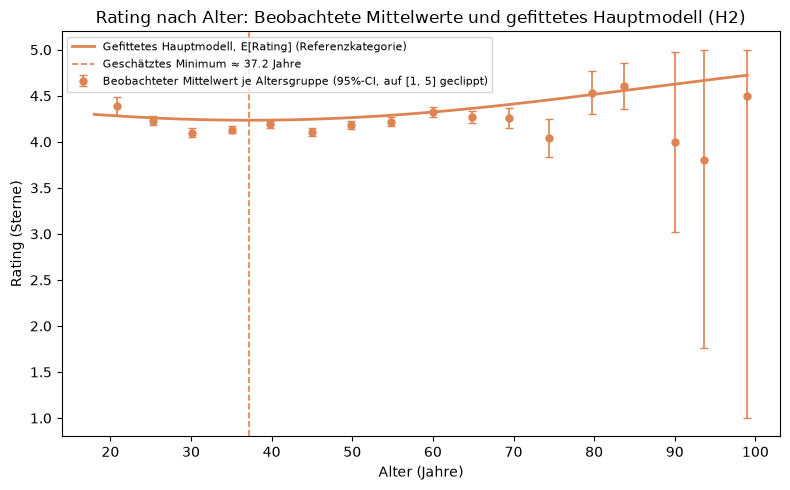

Geschätztes Minimum H2-Hauptmodell (für Grafik verwendet): 37.23 Jahre


,Altersgruppe,rating_mean,rating_std,n,age_mean_obs,sem,ci95,ci_lower,ci_upper
0,18-22,4.392765,0.974147,387,20.852713,0.049519,0.097360,4.295405,4.490125
1,23-27,4.231367,1.056878,1543,25.225535,0.026906,0.052775,4.178592,4.284143
2,28-32,4.100657,1.163272,2434,30.173377,0.023579,0.046237,4.054421,4.146894
3,33-37,4.132969,1.144783,3843,35.023159,0.018467,0.036205,4.096764,4.169174
4,38-42,4.189342,1.085419,3903,39.805022,0.017374,0.034063,4.155279,4.223404
5,43-47,4.110766,1.153620,2898,45.025880,0.021430,0.042019,4.068747,4.152785
6,48-52,4.183260,1.106446,2270,49.798678,0.023223,0.045540,4.137719,4.228800
7,53-57,4.216269,1.109936,2053,54.853385,0.024496,0.048041,4.168228,4.264309
8,58-62,4.326116,1.057203,1478,60.014885,0.027499,0.053942,4.272175,4.380058
9,63-67,4.271186,1.087083,1121,64.886708,0.032468,0.063706,4.207481,4.334892


In [38]:
from scipy.stats import t as t_dist

# Dieselben 5-Jahres-Altersgruppen wie bei H1
h2_age_bin_edges = list(range(18, 99, 5)) + [100]
h2_age_bin_labels = [f"{h2_age_bin_edges[i]}-{h2_age_bin_edges[i + 1] - 1}" for i in range(len(h2_age_bin_edges) - 1)]
h2_age_groups = pd.cut(df["Age"], bins=h2_age_bin_edges, right=False, labels=h2_age_bin_labels)

h2_group_stats = df.groupby(h2_age_groups, observed=True)["Rating"].agg(["mean", "std", "size"]).reset_index()
h2_group_stats.columns = ["Altersgruppe", "rating_mean", "rating_std", "n"]
h2_group_stats["age_mean_obs"] = df.groupby(h2_age_groups, observed=True)["Age"].mean().values
h2_group_stats["sem"] = h2_group_stats["rating_std"] / np.sqrt(h2_group_stats["n"])
h2_group_stats["ci95"] = h2_group_stats["sem"] * t_dist.ppf(0.975, h2_group_stats["n"] - 1)

# CI-Grenzen auf den gültigen Wertebereich von Rating [1, 5] clippen (nur die Fehlerbalken,
# nicht der Punktschätzer selbst, der ohnehin stets im gültigen Bereich liegt). Bei kleinen
# Altersgruppen (v.a. am oberen Altersrand) reicht das unclippte CI sonst ausserhalb dieses Bereichs.
h2_group_stats["ci_lower"] = (h2_group_stats["rating_mean"] - h2_group_stats["ci95"]).clip(lower=1.0, upper=5.0)
h2_group_stats["ci_upper"] = (h2_group_stats["rating_mean"] + h2_group_stats["ci95"]).clip(lower=1.0, upper=5.0)
h2_yerr = np.vstack([
    h2_group_stats["rating_mean"] - h2_group_stats["ci_lower"],
    h2_group_stats["ci_upper"] - h2_group_stats["rating_mean"],
])

# Erwartete Rating-Kurve des H2-Hauptmodells an der Referenzkategorie (alle Dummy-Spalten = 0):
# E[Rating] = sum_k k * P(Rating = k)
h2_age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 300)
h2_newX = pd.DataFrame(0.0, index=range(len(h2_age_grid)), columns=X_haupt.columns)
h2_newX["Age_c"] = h2_age_grid - age_mean
h2_newX["Age_c_sq"] = (h2_age_grid - age_mean) ** 2
h2_pred_probs = np.asarray(res_haupt.predict(h2_newX))
h2_expected_rating = h2_pred_probs @ np.array(RATING_CATEGORIES)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    h2_group_stats["age_mean_obs"], h2_group_stats["rating_mean"], yerr=h2_yerr,
    fmt="o", color="#DD8452", ecolor="#DD8452", elinewidth=1.2, capsize=3, markersize=5,
    label="Beobachteter Mittelwert je Altersgruppe (95%-CI, auf [1, 5] geclippt)",
)
ax.plot(h2_age_grid, h2_expected_rating, color="#DD8452", linewidth=2,
        label="Gefittetes Hauptmodell, E[Rating] (Referenzkategorie)")
ax.axvline(tp_haupt, color="#DD8452", linestyle="--", linewidth=1.2,
           label=f"Geschätztes Minimum \u2248 {tp_haupt:.1f} Jahre")
ax.set_xlabel("Alter (Jahre)")
ax.set_ylabel("Rating (Sterne)")
ax.set_title("Rating nach Alter: Beobachtete Mittelwerte und gefittetes Hauptmodell (H2)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "h2_age_fitted_curve.png", dpi=150)
plt.show()

print(f"Geschätztes Minimum H2-Hauptmodell (für Grafik verwendet): {tp_haupt:.2f} Jahre")
h2_group_stats

 Wie bereits bei H1 spiegelt die zunehmende Breite der Konfidenzintervalle in den höchsten Altersgruppen die dort sehr geringe Fallzahl wider. Die älteste Altersgruppe von 98 bis 99 Jahren umfasst lediglich 2 Beobachtungen, während für die Altersgruppe von 93 bis 97 Jahren nur 5 Beobachtungen vorliegen. Die Ergebnisse in diesen Altersbereichen sind daher mit entsprechend hoher Unsicherheit verbunden und sollten vorsichtig interpretiert werden.

## Proportional-Odds-Annahme testen (Brant 1990, Separate-Fits-Ansatz)

Die Proportional Odds Annahme wird für das Basismodell und das Hauptmodell mit zentrierter Altersvariable geprüft. Die beiden Robustheitsmodelle dienen der zusätzlichen Überprüfung der Stabilität der zentralen Modellergebnisse und werden aus Aufwandsgründen nicht separat auf die Proportional Odds Annahme getestet. Da die Zentrierung der Altersvariable eine reine Reparametrisierung darstellt, bleiben die entsprechenden Wald beziehungsweise LR Statistiken unter der zentrierten und der unzentrierten Spezifikation bis auf mögliche numerische Rundungsabweichungen unverändert. Die Prüfung erfolgt daher direkt anhand der zentrierten finalen Modelle.

1. Für jede Schwelle `j` wird ein separates binäres Logit Modell (`sm.Logit`) mit denselben Prädiktoren wie im jeweiligen `OrderedModel` geschätzt. Daraus ergeben sich der    Koeffizientenvektor `β_j` und die zugehörige Kovarianzmatrix `V_jj = (X'W_jX)⁻¹`, wobei `W_j = diag(π_j(1 − π_j))` gilt.
2. Die Kovarianz zwischen zwei Schwellenmodellen `j < l` wird nach Brants Formel als `V_jl = (X'W_jX)⁻¹ (X'W_jlX) (X'W_lX)⁻¹` berechnet, wobei `W_jl = diag(π_l − π_j · π_l)` gilt.
3. Aus diesen Blöcken wird die vollständige Kovarianzmatrix `V` des gestapelten Koeffizientenvektors `β = (β_1', …, β_{K−1}')'` gebildet.
4. Eine Kontrastmatrix `D` bildet die Differenzen der Steigungskoeffizienten ohne Konstanten zwischen aufeinanderfolgenden Schwellen ab.
5. Die Wald Statistik wird als `χ² = (Dβ)' [D · V · D']⁻¹ (Dβ)` berechnet. Für den Omnibus Test ergeben sich `df = (K − 2) · p` Freiheitsgrade. Ergänzend wird die Proportional Odds Annahme für jede Prädiktorvariable separat mit jeweils `df = K − 2 = 3` Freiheitsgraden geprüft. Die zugehörigen p Werte werden anhand der Chi Quadrat Verteilung bestimmt.


Zusätzlich zu den Tests der einzelnen Prädiktorvariablen wird ein gemeinsamer Blocktest für `Age_c` und `Age_c_sq` berechnet (`groups=...`). Der Test eines einzelnen Altersterms ist nicht invariant gegenüber der Zentrierung, da sich durch die Zentrierung die Parametrisierung des linearen und quadratischen Altersterms verändert. Der gemeinsame Blocktest über beide Altersterme prüft dagegen die vom gewählten Koordinatensystem unabhängige Hypothese, ob der Alterseffekt insgesamt über alle Schwellen konstant ist. Im Gegensatz zum separaten Test von `age_c` liefert der gemeinsame Blocktest somit ein gegenüber der Zentrierung invariantes und für die Interpretation des Alterseffekts geeigneteres Ergebnis.

In [39]:
def fit_threshold_logits(X_with_const, y, thresholds):
    """Fit ein binäres Logit-Modell je kumulativer Schwelle (Rating > j)."""
    results, pi_hats = [], []
    for j in thresholds:
        y_bin = (y > j).astype(int)
        m = sm.Logit(y_bin, X_with_const).fit(disp=False, maxiter=200)
        results.append(m)
        pi_hats.append(m.predict(X_with_const))
    return results, pi_hats


def stacked_covariance(X_with_const, logit_results, pi_hats):
    """Blockmatrix der Kovarianzen der gestapelten Schwellen-Koeffizienten (Brant 1990)."""
    Xmat = X_with_const.values
    p_full = Xmat.shape[1]
    n_thresh = len(logit_results)

    W = [pi.values * (1 - pi.values) for pi in pi_hats]
    XtWjX_inv = [np.linalg.inv(Xmat.T @ (w[:, None] * Xmat)) for w in W]

    V = np.zeros((n_thresh * p_full, n_thresh * p_full))
    for j in range(n_thresh):
        V[j * p_full:(j + 1) * p_full, j * p_full:(j + 1) * p_full] = XtWjX_inv[j]
        for l in range(j + 1, n_thresh):
            Wjl = pi_hats[l].values - pi_hats[j].values * pi_hats[l].values
            XtWjlX = Xmat.T @ (Wjl[:, None] * Xmat)
            block = XtWjX_inv[j] @ XtWjlX @ XtWjX_inv[l]
            V[j * p_full:(j + 1) * p_full, l * p_full:(l + 1) * p_full] = block
            V[l * p_full:(l + 1) * p_full, j * p_full:(j + 1) * p_full] = block.T
    return V


def contrast_matrix(p_full, n_thresh, slope_idx):
    """D-Matrix: Differenzen der Steigungskoeffizienten zwischen aufeinanderfolgenden Schwellen."""
    n_gaps = n_thresh - 1
    D = np.zeros((n_gaps * len(slope_idx), n_thresh * p_full))
    row = 0
    for k in slope_idx:
        for m in range(n_gaps):
            D[row, m * p_full + k] = 1
            D[row, (m + 1) * p_full + k] = -1
            row += 1
    return D, n_gaps


def _wald_from_contrast(D_sub, beta_stack, V):
    """Wald-Statistik + p-Wert für eine beliebige Kontrast-Teilmatrix D_sub."""
    Db = D_sub @ beta_stack
    DVDt = D_sub @ V @ D_sub.T
    stat = float(Db @ np.linalg.solve(DVDt, Db))
    df = D_sub.shape[0]
    p = float(1 - chi2.cdf(stat, df))
    return stat, df, p


def brant_test(X_with_const, y, thresholds, model_label, groups=None):
    """Brant-Test (Wald, Separate-Fits): Omnibus + je Prädiktor + optionale Variablen-Gruppen.

    `groups`: dict {Bezeichnung: [Spaltennamen]} für gemeinsame Blocktests mehrerer Prädiktoren
    (z. B. lineares + quadratisches Alter zusammen). Ein solcher Gruppentest ist, anders als der
    Test einer einzelnen Spalte, invariant gegenüber linearen Reparametrisierungen (z. B.
    Zentrierung) *innerhalb* der Gruppe, da er die gemeinsam aufgespannte Teilraum-Hypothese prüft
    statt einer einzelnen, basisabhängigen Koordinate."""
    logit_results, pi_hats = fit_threshold_logits(X_with_const, y, thresholds)
    beta_stack = np.concatenate([m.params.values for m in logit_results])
    V = stacked_covariance(X_with_const, logit_results, pi_hats)

    p_full = X_with_const.shape[1]
    n_thresh = len(thresholds)
    slope_names = list(X_with_const.columns[1:])  # ohne Konstante
    slope_idx = list(range(1, p_full))

    D, n_gaps = contrast_matrix(p_full, n_thresh, slope_idx)
    wald_omnibus, df_omnibus, p_omnibus = _wald_from_contrast(D, beta_stack, V)

    rows = [{
        "Modell": model_label, "Test": "Brant (Wald)", "Variable": "Omnibus (alle Prädiktoren)",
        "Statistik": wald_omnibus, "df": df_omnibus, "p_Wert": p_omnibus,
    }]

    for i, name in enumerate(slope_names):
        Dk = D[i * n_gaps:(i + 1) * n_gaps, :]
        wald_k, df_k, p_k = _wald_from_contrast(Dk, beta_stack, V)
        rows.append({
            "Modell": model_label, "Test": "Brant (Wald)", "Variable": name,
            "Statistik": wald_k, "df": df_k, "p_Wert": p_k,
        })

    for group_label, group_cols in (groups or {}).items():
        rel_positions = [slope_names.index(c) for c in group_cols]
        row_idx = np.concatenate([np.arange(i * n_gaps, (i + 1) * n_gaps) for i in rel_positions])
        D_group = D[row_idx, :]
        wald_g, df_g, p_g = _wald_from_contrast(D_group, beta_stack, V)
        rows.append({
            "Modell": model_label, "Test": "Brant (Wald, gemeinsamer Block)", "Variable": group_label,
            "Statistik": wald_g, "df": df_g, "p_Wert": p_g,
        })

    return pd.DataFrame(rows)

In [40]:
brant_basis = brant_test(
    sm.add_constant(X_basis), h2_df["Rating"].astype(int), THRESHOLDS, "Basismodell",
    groups={"Age-Block (Age_c + Age_c_sq, gemeinsam)": ["Age_c", "Age_c_sq"]},
)
brant_basis

,Modell,Test,Variable,Statistik,df,p_Wert
0,Basismodell,Brant (Wald),Omnibus (alle Prädiktoren),21.367622,6,0.001575
1,Basismodell,Brant (Wald),Age_c,11.440555,3,0.009567
2,Basismodell,Brant (Wald),Age_c_sq,5.474063,3,0.140198
3,Basismodell,"Brant (Wald, gemeinsamer Block)","Age-Block (Age_c + Age_c_sq, gemeinsam)",21.367622,6,0.001575


Der Omnibus Test über alle Prädiktoren ist statistisch signifikant (p = 0,0016) und weist damit auf eine Verletzung der Proportional Odds Annahme im Basismodell hin. Bei den Einzeltests ist `age_c` signifikant (p = 0,0096), während für `age_c_sq` kein statistisch signifikanter Hinweis auf eine Verletzung der Annahme vorliegt (p = 0,14). Der Einzeltest von `age_c` ist aufgrund seiner Abhängigkeit von der gewählten Zentrierung jedoch nur eingeschränkt isoliert zu interpretieren. Da das Basismodell ausschliesslich `age_c` und `age_c_sq` als Prädiktoren enthält, entspricht der gemeinsame Age Block Test dem Omnibus Test. Dieser bestätigt mit p = 0,0016, dass die Proportional Odds Annahme für den Alterseffekt insgesamt im Basismodell verletzt ist.

In [41]:
brant_haupt = brant_test(
    sm.add_constant(X_haupt), h2_df_haupt["Rating"].astype(int), THRESHOLDS, "Hauptmodell",
    groups={"Age-Block (Age_c + Age_c_sq, gemeinsam)": ["Age_c", "Age_c_sq"]},
)
brant_haupt

,Modell,Test,Variable,Statistik,df,p_Wert
0,Hauptmodell,Brant (Wald),Omnibus (alle Prädiktoren),50.583110,27,0.003895
1,Hauptmodell,Brant (Wald),Age_c,11.409172,3,0.009707
2,Hauptmodell,Brant (Wald),Age_c_sq,5.283277,3,0.152191
3,Hauptmodell,Brant (Wald),Division_General Petite,3.436252,3,0.329125
4,Hauptmodell,Brant (Wald),Division_Initmates,0.486826,3,0.921776
5,Hauptmodell,Brant (Wald),Department_Dresses,1.928619,3,0.587353
6,Hauptmodell,Brant (Wald),Department_Intimate,0.985220,3,0.804828
7,Hauptmodell,Brant (Wald),Department_Jackets,10.668267,3,0.013662
8,Hauptmodell,Brant (Wald),Department_Tops,1.638588,3,0.650672
9,Hauptmodell,Brant (Wald),Department_Trend,1.665889,3,0.644544


Auch im Hauptmodell ist der Omnibus Test statistisch signifikant und weist damit auf eine Verletzung der Proportional Odds Annahme hin. Der gemeinsame Age Block Test zeigt ebenfalls eine deutliche Verletzung der Annahme (p = 0,0019) und liegt damit sehr nahe am Ergebnis des Basismodells (p = 0,0016). Die nahezu identischen Ergebnisse sprechen dafür, dass der Befund für den Alterseffekt gegenüber der zusätzlichen Berücksichtigung der Kontrollvariablen `Division Name` und `Department Name` weitgehend stabil bleibt.

**Kontrolle der Invarianz:** Im Basismodell umfasst der Omnibus Test ausschliesslich `Age_c` und `Age_c_sq`. Der gemeinsame Age Block Test sollte daher bis auf mögliche numerische Rundungsabweichungen mit dem Omnibus Test übereinstimmen. Im Hauptmodell liefert der Age Block Test die gegenüber der Zentrierung beziehungsweise Parametrisierung invariante Aussage zum Alterseffekt insgesamt. Dies unterscheidet ihn vom separaten Test der einzelnen `Age_c` Zeile, dessen Ergebnis sich beim Wechsel zwischen unzentrierter und zentrierter Altersspezifikation verändern kann.


In [42]:
age_block_basis = brant_basis.loc[brant_basis["Variable"].str.contains("Age-Block"), ["Modell", "Variable", "Statistik", "df", "p_Wert"]]
omnibus_basis = brant_basis.loc[brant_basis["Variable"] == "Omnibus (alle Prädiktoren)", ["Modell", "Variable", "Statistik", "df", "p_Wert"]]
age_block_haupt = brant_haupt.loc[brant_haupt["Variable"].str.contains("Age-Block"), ["Modell", "Variable", "Statistik", "df", "p_Wert"]]
pd.concat([omnibus_basis, age_block_basis, age_block_haupt], ignore_index=True)

,Modell,Variable,Statistik,df,p_Wert
0,Basismodell,Omnibus (alle Prädiktoren),21.367622,6,0.001575
1,Basismodell,"Age-Block (Age_c + Age_c_sq, gemeinsam)",21.367622,6,0.001575
2,Hauptmodell,"Age-Block (Age_c + Age_c_sq, gemeinsam)",20.947558,6,0.001875


Die Tabelle bestätigt die erwartete Invarianz: Im Basismodell stimmt die Omnibus Statistik (21,37) exakt mit der Statistik des Age Block Tests (21,37) überein. Sowohl im Basis als auch im Hauptmodell ist die Proportional Odds Annahme für den Alterseffekt verletzt. Der Age Block Test ist in beiden Modellen statistisch signifikant (Basismodell: p = 0,0016; Hauptmodell: p = 0,0019). Dies deutet darauf hin, dass der Zusammenhang von `Age_c` und `Age_c_sq` mit dem Rating nicht über alle Rating Schwellen hinweg konstant ausgeprägt ist. Dieser Befund stellt eine methodische Limitation der H2 Analyse dar und wird entsprechend in den Kapiteln 4, 5 und 6 berücksichtigt. Die Koeffizienten des Proportional Odds Modells können weiterhin als unter der Modellrestriktion geschätzte durchschnittliche Zusammenhänge interpretiert werden. Aufgrund der nachgewiesenen Verletzung der Proportional Odds Annahme ist ihre Interpretation als über alle Rating Schwellen hinweg konstante Effekte jedoch mit entsprechender Vorsicht vorzunehmen.

## Likelihood-Ratio-Test als Cross-Check (MNLogit vs. OrderedModel)

`LR = 2·(llf_voll - llf_reduziert)`, `df = (K-2)·p`, `p`-Wert über die Chi²-Verteilung.

Dies stellt eine zweite, methodisch unabhängige Prüfung derselben Modellannahme wie beim Brant Test dar, verwendet jedoch einen anderen Ansatz. Während beim Brant Test separate binäre Logit Modelle über die verschiedenen Schwellen hinweg verglichen werden, wird hier die Modellanpassung anhand der Log Likelihood des restringierten `OrderedModel` mit jener eines weniger restriktiven `MNLogit` Modells verglichen. Das multinomiale Logit Modell unterliegt nicht der Proportional Odds Restriktion und schätzt für die einzelnen Kategorien separate Koeffizienten.

In [43]:
def mnlogit_lr_test(X_with_const, y, llf_reduced, p_slopes, model_label):
    mn = sm.MNLogit(y, X_with_const).fit(method="newton", disp=False, maxiter=200)
    lr_stat = 2 * (mn.llf - llf_reduced)
    df_lr = (K - 2) * p_slopes
    p_lr = float(1 - chi2.cdf(lr_stat, df_lr))
    return pd.DataFrame([{
        "Modell": model_label, "Test": "Likelihood-Ratio (MNLogit vs. OrderedModel)",
        "Variable": "Omnibus (alle Prädiktoren)", "Statistik": lr_stat, "df": df_lr, "p_Wert": p_lr,
    }])


lr_basis = mnlogit_lr_test(sm.add_constant(X_basis), h2_df["Rating"].astype(int), res_basis.llf, X_basis.shape[1], "Basismodell")
lr_haupt = mnlogit_lr_test(sm.add_constant(X_haupt), h2_df_haupt["Rating"].astype(int), res_haupt.llf, X_haupt.shape[1], "Hauptmodell")

pd.concat([lr_basis, lr_haupt], ignore_index=True)

,Modell,Test,Variable,Statistik,df,p_Wert
0,Basismodell,Likelihood-Ratio (MNLogit vs. OrderedModel),Omnibus (alle Prädiktoren),19.539337,6,0.003343
1,Hauptmodell,Likelihood-Ratio (MNLogit vs. OrderedModel),Omnibus (alle Prädiktoren),45.920133,27,0.012977


Beide Tests sind statistisch signifikant (p < 0,05) und liefern damit unabhängig vom Brant Test denselben Befund: Die Proportional Odds Annahme ist verletzt.

## Zusammenfassung der Testergebnisse

`p > .05` → Proportional-Odds-Annahme für diesen Test/diese Variable **erfüllt**;
`p < .05` → Annahme **verletzt**.

In [44]:
h2_test_results = pd.concat([brant_basis, brant_haupt, lr_basis, lr_haupt], ignore_index=True)
h2_test_results["Interpretation"] = h2_test_results["p_Wert"].apply(
    lambda p: "Annahme erfüllt (p > .05)" if p > 0.05 else "Annahme verletzt (p < .05)"
)
h2_test_results

,Modell,Test,Variable,Statistik,df,p_Wert,Interpretation
0,Basismodell,Brant (Wald),Omnibus (alle Prädiktoren),21.367622,6,0.001575,Annahme verletzt (p < .05)
1,Basismodell,Brant (Wald),Age_c,11.440555,3,0.009567,Annahme verletzt (p < .05)
2,Basismodell,Brant (Wald),Age_c_sq,5.474063,3,0.140198,Annahme erfüllt (p > .05)
3,Basismodell,"Brant (Wald, gemeinsamer Block)","Age-Block (Age_c + Age_c_sq, gemeinsam)",21.367622,6,0.001575,Annahme verletzt (p < .05)
4,Hauptmodell,Brant (Wald),Omnibus (alle Prädiktoren),50.583110,27,0.003895,Annahme verletzt (p < .05)
5,Hauptmodell,Brant (Wald),Age_c,11.409172,3,0.009707,Annahme verletzt (p < .05)
6,Hauptmodell,Brant (Wald),Age_c_sq,5.283277,3,0.152191,Annahme erfüllt (p > .05)
7,Hauptmodell,Brant (Wald),Division_General Petite,3.436252,3,0.329125,Annahme erfüllt (p > .05)
8,Hauptmodell,Brant (Wald),Division_Initmates,0.486826,3,0.921776,Annahme erfüllt (p > .05)
9,Hauptmodell,Brant (Wald),Department_Dresses,1.928619,3,0.587353,Annahme erfüllt (p > .05)


**Was bedeuten Wald- und LR-Statistik technisch?**

-  **Wald Statistik (Brant Test):** Diese prüft, in welchem Ausmass die separat geschätzten Steigungskoeffizienten der `K − 1` Schwellen Logit Modelle voneinander abweichen. Die Abweichungen werden dabei relativ zu ihrer gemeinsamen Stichprobenunsicherheit auf Basis der Kovarianzmatrix bewertet.
-  **Likelihood Ratio Statistik:** Diese vergleicht direkt die Modellanpassung anhand der Log Likelihood des restringierten `OrderedModel` mit jener eines weniger restriktiven     multinomialen Logit Modells (`MNLogit`).
-  Unter der Nullhypothese folgen beide Teststatistiken asymptotisch einer Chi Quadrat Verteilung mit `df = (K − 2) · p` Freiheitsgraden.



## Ergebnistabelle & Speichern

In [45]:
h2_models = {
    "Basismodell": (res_basis, tp_basis),
    "Hauptmodell": (res_haupt, tp_haupt),
    "Robustheitsmodell A (+ Recommended IND)": (res_robust_a, tp_robust_a),
    "Robustheitsmodell B (+ Positive Feedback Count)": (res_robust_b, tp_robust_b),
}

h2_coef_rows = pd.concat(
    [params_table(res, label) for label, (res, _tp) in h2_models.items()],
    ignore_index=True,
)

h2_summary_rows = []
for label, (res, tp) in h2_models.items():
    cond_row = h2_cond_check.loc[h2_cond_check["Modelltyp"] == label]
    cond_raw = cond_row["Cond_No_roh"].iloc[0] if len(cond_row) else np.nan
    cond_c = cond_row["Cond_No_zentriert"].iloc[0] if len(cond_row) else np.nan
    for term, value in [
        ("Geschätztes Minimum (Age)", tp),
        ("McFadden Pseudo-R2", res.prsquared),
        ("AIC", res.aic),
        ("N", res.nobs),
        ("Condition Number (roh)", cond_raw),
        ("Condition Number (zentriert)", cond_c),
    ]:
        h2_summary_rows.append({"Modelltyp": label, "Term": term, "Koeffizient": value})

h2_results_updated = pd.concat([h2_coef_rows, pd.DataFrame(h2_summary_rows)], ignore_index=True)
h2_results_updated.to_csv(RESULTS_DIR / "h2_ordinal_regression_updated.csv", index=False)
h2_results_updated

,Modelltyp,Term,Koeffizient,SE,Statistik,p_Wert
0,Basismodell,Age_c,0.003947,0.001120,3.522722,0.000427
1,Basismodell,Age_c_sq,0.000335,0.000069,4.828083,0.000001
2,Basismodell,1/2,-3.233693,0.036926,-87.572968,0.000000
3,Basismodell,2/3,0.125786,0.025856,4.864883,0.000001
4,Basismodell,3/4,-0.066752,0.018252,-3.657319,0.000255
...,...,...,...,...,...,...
66,Robustheitsmodell B (+ Positive Feedback Count),McFadden Pseudo-R2,0.003694,NaN,NaN,NaN
67,Robustheitsmodell B (+ Positive Feedback Count),AIC,55143.557399,NaN,NaN,NaN
68,Robustheitsmodell B (+ Positive Feedback Count),N,22627.000000,NaN,NaN,NaN
69,Robustheitsmodell B (+ Positive Feedback Count),Condition Number (roh),34501.322173,NaN,NaN,NaN


In [46]:
h2_test_results.to_csv(RESULTS_DIR / "h2_proportional_odds_tests.csv", index=False)
h2_fit_stats.to_csv(RESULTS_DIR / "h2_ordinal_fit_stats.csv")

sorted(p.name for p in RESULTS_DIR.glob("h2_*"))

['h2_department_jackets_thresholds.csv',
 'h2_ordinal_fit_stats.csv',
 'h2_ordinal_regression_updated.csv',
 'h2_proportional_odds_tests.csv']

## Exkurs: Zwei Konsistenzprüfungen vor Übernahme in die Thesis

### 1. Vergleichbarkeit der Condition Number zwischen H1 (OLS) und H2 (OrderedModel)

Die Condition Number der unzentrierten Designmatrix unterscheidet sich im Basismodell deutlich zwischen H1 und H2, obwohl beide Modelle lediglich `Age` und `Age²` als Prädiktoren enthalten. Der Unterschied ist auf die jeweilige Modellierungskonvention zurückzuführen. `smf.ols` fügt bei der Verwendung einer Formel automatisch eine Konstantenspalte zur Designmatrix hinzu. Beim `OrderedModel` wird hingegen keine separate Konstante in die Prädiktormatrix aufgenommen, da die frei geschätzten Schwellenwerte die Lageparameter zwischen den ordinalen Kategorien abbilden. Die Designmatrix enthält dort somit lediglich `Age` und `Age²`. Die zusätzliche Konstantenspalte kann in Kombination mit Prädiktoren, deren Werte deutlich von null entfernt liegen, die numerische Konditionierung der Designmatrix erheblich verschlechtern und damit die Condition Number erhöhen. Dieser Zusammenhang wird im Folgenden anhand identischer Designmatrizen verdeutlicht.

In [47]:
cond_compare = pd.DataFrame([
    {"Variante": "roh, ohne Konstante", "Cond_No": cond_number(df[["Age", "Age_sq"]].values), "entspricht": "H2-Konvention (OrderedModel)"},
    {"Variante": "roh, mit Konstante", "Cond_No": cond_number(sm.add_constant(df[["Age", "Age_sq"]]).values), "entspricht": "H1-Konvention (OLS)"},
    {"Variante": "zentriert, ohne Konstante", "Cond_No": cond_number(df[["Age_c", "Age_c_sq"]].values), "entspricht": "H2-Konvention (OrderedModel)"},
    {"Variante": "zentriert, mit Konstante", "Cond_No": cond_number(sm.add_constant(df[["Age_c", "Age_c_sq"]]).values), "entspricht": "H1-Konvention (OLS)"},
])
cond_compare

,Variante,Cond_No,entspricht
0,"roh, ohne Konstante",208.988328,H2-Konvention (OrderedModel)
1,"roh, mit Konstante",25703.825235,H1-Konvention (OLS)
2,"zentriert, ohne Konstante",21.927050,H2-Konvention (OrderedModel)
3,"zentriert, mit Konstante",328.065154,H1-Konvention (OLS)


**Ergebnis:** Die Werte der Designmatrix ohne Konstantenspalte entsprechen exakt den bisher für H2 berichteten Werten, während die Werte der Designmatrix mit Konstantenspalte exakt den bisher für H1 berichteten Werten entsprechen. Dabei liegen beiden Berechnungen identische `Age` Daten zugrunde. Die scheinbar grosse Diskrepanz der Condition Number zwischen H1 und H2 lässt sich somit vollständig durch die unterschiedliche Modellierungskonvention erklären, also durch das Vorhandensein beziehungsweise Fehlen einer Konstantenspalte in der Designmatrix. Sie ist nicht auf einen tatsächlichen Unterschied in der Kollinearität zwischen `Age` und `Age²` in den beiden Hypothesen zurückzuführen. Die Zentrierung reduziert die Condition Number unter beiden Modellierungskonventionen deutlich und verbessert damit die numerische Konditionierung der jeweiligen Designmatrix.

### 2. Department Jackets: schwellenspezifische Koeffizienten (Brant-Diagnostik)

`Department: Jackets` ist im gepoolten `OrderedModel` Hauptmodell nicht statistisch signifikant, weist im Brant Test jedoch auf eine Verletzung der Proportional Odds Annahme hin. Dies stellt keinen Widerspruch dar. Das `OrderedModel` schätzt unter der Proportional Odds Annahme einen gemeinsamen Koeffizienten für alle vier Schwellen. Unterscheiden sich die geschätzten Effekte zwischen den einzelnen Schwellen deutlich, kann dieser gemeinsame Koeffizient nahe null liegen und statistisch nicht signifikant sein, obwohl für einzelne Schwellen stärkere positive oder negative Zusammenhänge vorliegen. Die vier separat geschätzten Schwellen Logit Modelle aus der Brant Test Pipeline veranschaulichen diese Unterschiede direkt:

In [48]:
jackets_logits, _ = fit_threshold_logits(sm.add_constant(X_haupt), h2_df_haupt["Rating"].astype(int), THRESHOLDS)

jackets_by_threshold = pd.DataFrame([
    {
        "Schwelle": f"Rating > {j}",
        "Koeffizient": m.params["Department_Jackets"],
        "SE": m.bse["Department_Jackets"],
        "z": m.tvalues["Department_Jackets"],
        "p_Wert": m.pvalues["Department_Jackets"],
    }
    for j, m in zip(THRESHOLDS, jackets_logits)
])
jackets_by_threshold

,Schwelle,Koeffizient,SE,z,p_Wert
0,Rating > 1,-0.444858,0.176013,-2.527411,0.011491
1,Rating > 2,-0.251749,0.117690,-2.139086,0.032429
2,Rating > 3,-0.014524,0.089653,-0.162001,0.871305
3,Rating > 4,0.039107,0.073083,0.535106,0.592577


In [49]:
jackets_by_threshold.to_csv(RESULTS_DIR / "h2_department_jackets_thresholds.csv", index=False)
RESULTS_DIR / "h2_department_jackets_thresholds.csv"

PosixPath('/Users/laraeibel/Desktop/Bachelorarbeit_Python/results/h2_department_jackets_thresholds.csv')

**Ergebnis:** Der geschätzte Effekt von Department: Jackets ist nicht über alle Schwellen hinweg konstant. An den unteren Schwellen (`Rating > 1`, `Rating > 2`) zeigen sich statistisch signifikante negative Koeffizienten. An den oberen Schwellen (`Rating > 3`, `Rating > 4`)  liegen die geschätzten Koeffizienten hingegen nahe null und sind statistisch nicht signifikant.

**Interpretation:** Jacken Reviews weisen im Vergleich zur Referenzkategorie `Bottoms` an den unteren Schwellen (`Rating > 1` und `Rating > 2`) eine signifikant geringere Wahrscheinlichkeit auf, die jeweilige Rating Schwelle zu überschreiten. An den oberen Schwellen (`Rating > 3` und `Rating > 4`) unterscheiden sich Jacken hingegen nicht statistisch signifikant von der Referenzkategorie. Der gepoolte `OrderedModel` Koeffizient fasst diese unterschiedlichen Effekte über alle Schwellen hinweg in einem gemeinsamen Koeffizienten zusammen und erscheint dadurch insgesamt nicht signifikant. Genau dieses Muster wird durch den Brant Test erfasst und als Verletzung der Proportional Odds Annahme ausgewiesen. Es lässt sich somit festhalten, dass sich der Kategorieeffekt von Jacken insbesondere an den unteren Rating Schwellen zeigt und an den oberen Schwellen nicht statistisch nachweisbar ist. Die Verletzung der Proportional Odds Annahme verdeutlicht dabei, weshalb der gepoolte Koeffizient allein den schwellenabhängigen Zusammenhang für `Department: Jackets` nur unzureichend abbildet.


## H3: Zusammenhang Sentiment und Rating

H3 prüft den Zusammenhang zwischen den beiden Bewertungsmethoden, dem Freitext Sentiment (`VADER Compound`) und der Sternebewertung (`Rating`), ohne Alter oder weitere Kontrollvariablen. Dabei wird `VADER Compound` als Prädiktor für `Rating` modelliert. Diese Richtung folgt der inhaltlichen Annahme, dass das im Freitext ausgedrückte Sentiment die zugrunde liegende Kundenzufriedenheit widerspiegelt, die sich ebenfalls in der Sternebewertung äussert. Die gewählte Modellspezifikation stellt jedoch keinen empirischen Nachweis einer kausalen Wirkungsrichtung dar.

1. **Deskriptive Verteilungsanalyse**: Untersuchung der Verteilungsform von `Rating` und `VADER Compound`
2. **Rating ~ VADER Compound**: Ordinale logistische Regression einschliesslich Prüfung der Proportional Odds Annahme
3. **Vergleich**: Untersuchung der Stärke des Zusammenhangs mittels Pearson und Spearman Korrelation sowie Einordnung der Ergebnisse unter Berücksichtigung der Verteilungsformen


## Deskriptive Verteilungsanalyse (stark linksschief)


In [50]:
rating_dist = df["Rating"].value_counts(normalize=True).reindex([1, 2, 3, 4, 5])
rating_dist

Rating
1    0.036263
2    0.068419
3    0.124691
4    0.216784
5    0.553843
Name: proportion, dtype: float64

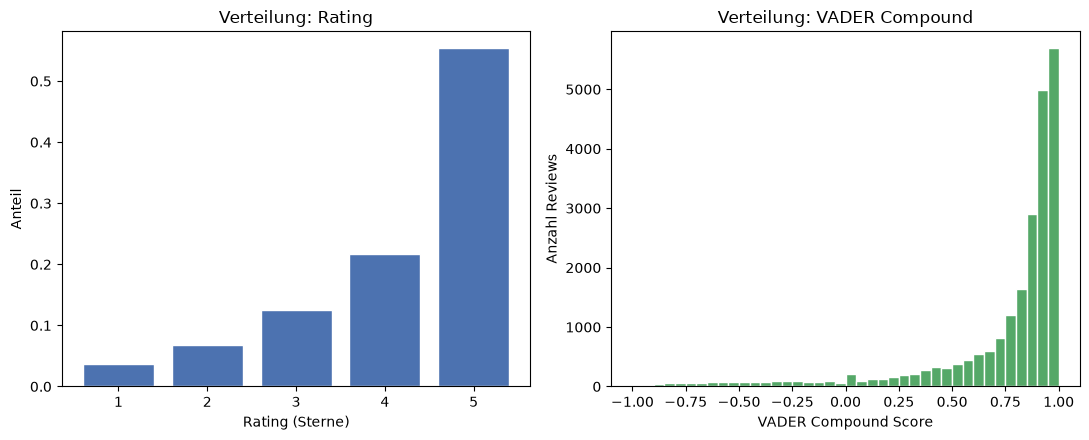

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(rating_dist.index, rating_dist.values, color="#4C72B0", edgecolor="white")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_xlabel("Rating (Sterne)")
axes[0].set_ylabel("Anteil")
axes[0].set_title("Verteilung: Rating")

axes[1].hist(df["VADER Compound"], bins=40, range=(-1, 1), color="#55A868", edgecolor="white")
axes[1].set_xlabel("VADER Compound Score")
axes[1].set_ylabel("Anzahl Reviews")
axes[1].set_title("Verteilung: VADER Compound")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "h3_rating_vs_compound_distribution.png", dpi=150)
plt.show()

Die Verteilung von `Rating` ist deutlich auf hohe Bewertungen konzentriert und weist eine linksschiefe Form auf. 5 Sterne dominieren mit 55,4 % aller Bewertungen, gefolgt von 4 Sternen (21,7 %), 3 Sternen (12,5 %), 2 Sternen (6,8 %) und 1 Stern als seltenster Kategorie (3,6 %). Die Häufigkeit nimmt von 5 bis 1 Stern durchgehend ab, sodass keine zweite Häufung am unteren Ende der Skala erkennbar ist. Auch `VADER Compound` ist linksschief verteilt, mit einer deutlichen Konzentration im stark positiven Bereich nahe +1 und einem längeren linken Ausläufer. Dieses Verteilungsmuster ist deskriptiv mit der bereits in der Residualdiagnostik von H1 beobachteten Linksschiefe der Residuen vereinbar, ohne dass daraus ein direkter kausaler Zusammenhang abgeleitet werden kann.

**Hinweis zur Einordnung:** Die hier beobachtete Rating Verteilung weicht von der in Teilen der Literatur berichteten bimodalen J Form ab, bei der neben einer Häufung am oberen Ende auch eine zweite, kleinere Häufung bei sehr niedrigen Bewertungen auftritt, etwa im Zusammenhang mit Selection Bias bei Online Bewertungen (Hu, Zhang und Pavlou, 2009). Im vorliegenden Datensatz fehlt diese zweite Häufung vollständig und die Verteilung ist durchgehend monoton fallend. Hu, Zhang und Pavlou (2009) dienen hier ausschliesslich als Kontrastpunkt aus der Literatur und nicht als Erklärung für das im vorliegenden Datensatz beobachtete Muster.


## Rating ~ VADER Compound (Ordinal Logit)

Für H3 wird analog zu H2 ein `OrderedModel` geschätzt, wobei `VADER Compound` als einziger Prädiktor verwendet wird. Alter und weitere Kontrollvariablen werden nicht in das Modell aufgenommen. Die Verwendung derselben Modellklasse und die zusätzliche Prüfung der Proportional Odds Annahme ermöglichen eine direkte methodische Vergleichbarkeit mit H2.



In [76]:
y_h3 = pd.Categorical(df["Rating"], categories=RATING_CATEGORIES, ordered=True)
X_h3 = df[["VADER Compound"]].rename(columns={"VADER Compound": "VADER_Compound"}).astype(float)

ordinal_h3 = OrderedModel(y_h3, X_h3, distr="logit")
res_h3 = ordinal_h3.fit(method="bfgs", disp=False, maxiter=200)
print(res_h3.summary())

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -25379.
Model:                   OrderedModel   AIC:                         5.077e+04
Method:            Maximum Likelihood   BIC:                         5.081e+04
Date:                Tue, 15 Sep 2026                                         
Time:                        08:42:16                                         
No. Observations:               22640                                         
Df Residuals:                   22635                                         
Df Model:                           1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
VADER_Compound     2.4008      0.037     64.499      0.000       2.328       2.474
1/2               -2.0284      0.040    

In [77]:
print(f"McFadden Pseudo-R2: {res_h3.prsquared:.4f}  (Log-L: {res_h3.llf:.1f}, Log-L Null: {res_h3.llnull:.1f})")
print(f"AIC: {res_h3.aic:.1f}")
print(f"N: {int(res_h3.nobs)}")

McFadden Pseudo-R2: 0.0827  (Log-L: -25378.5, Log-L Null: -27667.6)
AIC: 50767.0
N: 22640


**Proportional Odds Test (Brant, Wald):** Da das Modell lediglich `VADER Compound` als Prädiktor enthält, sind der Omnibus Test, der Einzelvariablen Test und der Block Test für `VADER Compound` inhaltlich und rechnerisch identisch. Alle drei Tests weisen `df = K − 2 = 3` Freiheitsgrade auf. Anders als bei H2 ist daher keine separate Betrachtung mehrerer zusammengehöriger Terme erforderlich, wie sie dort aufgrund der Zerlegung des Alterseffekts in `Age_c` und `Age_c_sq` vorgenommen wurde. Für H3 genügt somit ein einzelner Test, der mit derselben Brant Test Pipeline wie bei H2 durchgeführt wird und dadurch die methodische Konsistenz zwischen den Analysen gewährleistet.


In [78]:
brant_h3 = brant_test(sm.add_constant(X_h3), df["Rating"].astype(int), THRESHOLDS, "H3: Rating ~ VADER Compound")
brant_h3

,Modell,Test,Variable,Statistik,df,p_Wert
0,H3: Rating ~ VADER Compound,Brant (Wald),Omnibus (alle Prädiktoren),123.409342,3,0.0
1,H3: Rating ~ VADER Compound,Brant (Wald),VADER_Compound,123.409342,3,0.0


## Vergleich: Korrelationsstärke und Einordnung über die linksschiefe Rating-Verteilung


In [80]:
pearson_r, pearson_p = pearsonr(df["VADER Compound"], df["Rating"])
spearman_rho, spearman_p = spearmanr(df["VADER Compound"], df["Rating"])

h3_correlations = pd.DataFrame([
    {"Methode": "Pearson (linear)", "Koeffizient": pearson_r, "p_Wert": pearson_p},
    {"Methode": "Spearman (Rang)", "Koeffizient": spearman_rho, "p_Wert": spearman_p},
])
h3_correlations

,Methode,Koeffizient,p_Wert
0,Pearson (linear),0.473441,0.0
1,Spearman (Rang),0.432461,0.0


**Interpretation:** Pearson und Spearman Korrelation liegen erwartungsgemäss nahe beieinander (vgl. Zahlen oberhalb). Mit r ≈ 0,47 und ρ ≈ 0,43 zeigen beide einen positiven, moderaten Zusammenhang zwischen dem Sentiment im Freitext und der Sternebewertung. Die Koeffizienten liegen deutlich über null, zugleich aber ebenso deutlich unter einer perfekten Übereinstimmung (r = 1). Dieses Ergebnis ist mit der deskriptiven Verteilungsanalyse vereinbar: Die stark auf hohe Bewertungen konzentrierte und von 5 bis 1 Stern monoton abnehmende Verteilung von `Rating` bildet die Kundenerfahrung über lediglich fünf diskrete Kategorien ab, während `VADER Compound` eine feinere, kontinuierliche Abstufung des im Freitext ausgedrückten Sentiments ermöglicht. Reviews mit unterschiedlich ausgeprägtem Sentiment können dadurch derselben Rating Kategorie zugeordnet sein, insbesondere der stark besetzten Kategorie mit 5 Sternen. Umgekehrt können Reviews verschiedener Rating Stufen ähnliche Sentiment Werte aufweisen, beispielsweise bei sachlich formulierten 3 und 4 Sterne Reviews. `VADER Compound` und `Rating` erfassen somit deutlich verwandte, aber nicht vollständig übereinstimmende Aspekte der Kundenbewertung.

## Bootstrap-Vergleich der geschätzten Minima H1 vs. H2

Die geschätzten Minima der beiden U förmigen Alterskurven (H1: ≈ 47 Jahre; H2: ≈ 37 Jahre) wurden bisher lediglich anhand ihrer Punktschätzer gegenübergestellt. Im Folgenden wird mittels eines gepaarten Bootstraps geprüft, ob sich die Differenz zwischen den geschätzten Minima statistisch von null unterscheidet:

1. In jeder Bootstrap Iteration wird aus dem gemeinsamen Analysedatensatz mit N = 22'627 Beobachtungen ein Resample gleicher Grösse durch Ziehen der Zeilenindizes mit Zurücklegen erzeugt. Berücksichtigt werden dabei die Beobachtungen mit vorhandenen Angaben zu `Division Name` und `Department Name`. Für H1 und H2 werden dieselben gezogenen Indizes verwendet. Durch dieses gepaarte Vorgehen bleibt die Abhängigkeit zwischen den beiden Schätzungen innerhalb jedes Resamples erhalten, sodass die Differenz der geschätzten Minima unmittelbar bestimmt werden kann.
2. Auf jedem Resample werden das H1 Hauptmodell mittels OLS ohne `Recommended IND` und das H2 Hauptmodell mittels `OrderedModel` neu geschätzt. Anschliessend wird für beide Modelle das jeweilige geschätzte Minimum berechnet.
3. Aus den `N_BOOTSTRAP` resultierenden Differenzen zwischen dem geschätzten Minimum von H1 und dem geschätzten Minimum von H2 werden der Standardfehler, ein 95 % Perzentil Konfidenzintervall sowie ein näherungsweiser zweiseitiger bootstrapbasierter p Wert bestimmt.
4. Da die Bootstrap Verteilung der Differenz rechtsschief ist (siehe Diagnose weiter unten), wird ergänzend ein BCa Konfidenzintervall (bias corrected and accelerated) berechnet. Dieses berücksichtigt sowohl eine mögliche Verzerrung als auch die Asymmetrie der Bootstrap Verteilung und dient damit als ergänzende Intervallschätzung.

**Vereinfachung:** Die Alterszentrierung (`age_mean`) wird für alle Resamples auf den Mittelwert des Originaldatensatzes fixiert. Da die Zentrierung eine reine Verschiebung darstellt, beeinflusst dies die geschätzte Minimum Differenz nicht, vereinfacht jedoch die Implementierung.



In [56]:
N_BOOTSTRAP = 1000
BOOTSTRAP_SEED = 42

boot_base = df.dropna(subset=["Division Name", "Department Name"]).reset_index(drop=True).copy()
boot_base["Age_c"] = boot_base["Age"] - age_mean
boot_base["Age_c_sq"] = boot_base["Age_c"] ** 2

boot_h1 = boot_base.rename(columns={
    "VADER Compound": "vader_compound", "Age_c": "age_c", "Age_c_sq": "age_c_sq",
    "Division Name": "division_name", "Department Name": "department_name",
})

boot_division_dummies = pd.get_dummies(boot_base["Division Name"], prefix="Division", drop_first=True, dtype=float)
boot_department_dummies = pd.get_dummies(boot_base["Department Name"], prefix="Department", drop_first=True, dtype=float)
boot_X_h2 = pd.concat([boot_base[["Age_c", "Age_c_sq"]].astype(float), boot_division_dummies, boot_department_dummies], axis=1)
boot_y_h2_raw = boot_base["Rating"]

n_obs = len(boot_base)
rng = np.random.default_rng(BOOTSTRAP_SEED)

tp_h1_boot, tp_h2_boot = [], []
n_failed = 0

import time
_bootstrap_start = time.perf_counter()

for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, n_obs, size=n_obs)
    try:
        res1 = smf.ols(
            "vader_compound ~ age_c + age_c_sq + C(division_name) + C(department_name)",
            data=boot_h1.iloc[idx],
        ).fit()
        tp1 = turning_point(res1.params["age_c"], res1.params["age_c_sq"])

        X2 = boot_X_h2.iloc[idx].reset_index(drop=True)
        y2 = pd.Categorical(boot_y_h2_raw.iloc[idx].reset_index(drop=True), categories=RATING_CATEGORIES, ordered=True)
        res2 = OrderedModel(y2, X2, distr="logit").fit(method="bfgs", disp=False, maxiter=200)
        tp2 = turning_point(res2.params["Age_c"], res2.params["Age_c_sq"])
    except Exception:
        n_failed += 1
        continue

    tp_h1_boot.append(tp1)
    tp_h2_boot.append(tp2)

tp_h1_boot = np.array(tp_h1_boot)
tp_h2_boot = np.array(tp_h2_boot)
diff_boot = tp_h1_boot - tp_h2_boot

_bootstrap_elapsed = time.perf_counter() - _bootstrap_start

print(f"Erfolgreiche Resamples: {len(diff_boot)} / {N_BOOTSTRAP} (fehlgeschlagen: {n_failed})")
print(f"Laufzeit Bootstrap-Schleife: {_bootstrap_elapsed:.1f} Sekunden ({_bootstrap_elapsed / 60:.2f} Minuten)")


Erfolgreiche Resamples: 1000 / 1000 (fehlgeschlagen: 0)
Laufzeit Bootstrap-Schleife: 1538.6 Sekunden (25.64 Minuten)


In [57]:
diff_original = turning_point(h1_haupt.params["age_c"], h1_haupt.params["age_c_sq"]) - tp_haupt

diff_ci_low, diff_ci_high = np.percentile(diff_boot, [2.5, 97.5])
diff_se = diff_boot.std(ddof=1)
p_two_sided = 2 * min((diff_boot <= 0).mean(), (diff_boot >= 0).mean())
p_two_sided = min(p_two_sided, 1.0)

bootstrap_summary = pd.DataFrame([{
    "N_Bootstrap_erfolgreich": len(diff_boot),
    "N_Bootstrap_fehlgeschlagen": n_failed,
    "Geschätztes Minimum H1 (Original)": turning_point(h1_haupt.params["age_c"], h1_haupt.params["age_c_sq"]),
    "Geschätztes Minimum H2 (Original)": tp_haupt,
    "Differenz H1-H2 (Original)": diff_original,
    "Differenz Bootstrap-Mittelwert": diff_boot.mean(),
    "Bootstrap SE": diff_se,
    "95%-CI untere Grenze": diff_ci_low,
    "95%-CI obere Grenze": diff_ci_high,
    "p-Wert (zweiseitig, Anteils-basiert)": p_two_sided,
}])
bootstrap_summary

,N_Bootstrap_erfolgreich,N_Bootstrap_fehlgeschlagen,Geschätztes Minimum H1 (Original),Geschätztes Minimum H2 (Original),Differenz H1-H2 (Original),Differenz Bootstrap-Mittelwert,Bootstrap SE,95%-CI untere Grenze,95%-CI obere Grenze,"p-Wert (zweiseitig, Anteils-basiert)"
0,1000,0,47.422867,37.227537,10.19533,10.613676,4.349112,4.611098,20.263112,0.0


### BCa-Konfidenzintervall (bias-corrected and accelerated)

Die Bootstrap Verteilung der Minimum Differenz ist rechtsschief. Obwohl das Perzentil Konfidenzintervall keine symmetrische Verteilung voraussetzt, berücksichtigt es mögliche Verzerrungen und Schiefe nur eingeschränkt. Daher wird ergänzend ein BCa Konfidenzintervall berechnet.

`scipy.stats.bootstrap(..., method="BCa")` ist hier nicht direkt praktikabel, da dafür ein vollständiger Leave one out Jackknife mit N = 22'627 zusätzlichen OLS und `OrderedModel` Schätzungen erforderlich wäre. Daher wird die Standard BCa Formel nach Efron und Tibshirani (1993) manuell mit einem Gruppen Jackknife als recheneffizienter Näherung implementiert. Die Daten werden in `JACKKNIFE_GROUPS` zufällige, disjunkte Gruppen aufgeteilt und die Minimum Differenz jeweils unter Ausschluss einer Gruppe neu geschätzt.

**Hinweis zur methodischen Einordnung:** Die verwendete Formel für den Beschleunigungsparameter \(a\) ist die klassische Leave-one-out-Formel nach Efron und Tibshirani (1993), wird hier jedoch auf Gruppen-Jackknife-Werte statt auf Einzelbeobachtungswerte angewendet. Diese Übertragung dient als rechnerische Approximation. Ihre Eignung für das vorliegende Verfahren wurde nicht gesondert validiert. Das daraus berechnete BCa-Konfidenzintervall wird deshalb lediglich zu Dokumentationszwecken ausgewiesen und nicht zur zusätzlichen Absicherung des Befunds herangezogen.

In [58]:
from scipy.stats import norm

JACKKNIFE_GROUPS = 50
JACKKNIFE_SEED = 43

jack_rng = np.random.default_rng(JACKKNIFE_SEED)
group_id = jack_rng.integers(0, JACKKNIFE_GROUPS, size=n_obs)

diff_jack = []
for g in range(JACKKNIFE_GROUPS):
    keep = group_id != g
    res1_g = smf.ols(
        "vader_compound ~ age_c + age_c_sq + C(division_name) + C(department_name)",
        data=boot_h1.loc[keep],
    ).fit()
    tp1_g = turning_point(res1_g.params["age_c"], res1_g.params["age_c_sq"])

    X2_g = boot_X_h2.loc[keep].reset_index(drop=True)
    y2_g = pd.Categorical(boot_y_h2_raw.loc[keep].reset_index(drop=True), categories=RATING_CATEGORIES, ordered=True)
    res2_g = OrderedModel(y2_g, X2_g, distr="logit").fit(method="bfgs", disp=False, maxiter=200)
    tp2_g = turning_point(res2_g.params["Age_c"], res2_g.params["Age_c_sq"])

    diff_jack.append(tp1_g - tp2_g)

diff_jack = np.array(diff_jack)
jack_mean = diff_jack.mean()

# Bias-Korrektur z0: Anteil der Bootstrap-Resamples unterhalb der Original-Differenz
z0 = norm.ppf((diff_boot < diff_original).mean())

# Beschleunigung a (Efron & Tibshirani, 1993), hier auf Basis der Gruppen-Jackknife-Pseudowerte
a_hat = np.sum((jack_mean - diff_jack) ** 3) / (6 * (np.sum((jack_mean - diff_jack) ** 2)) ** 1.5)

alpha = 0.05
z_lo, z_hi = norm.ppf(alpha / 2), norm.ppf(1 - alpha / 2)

def bca_percentile(z0, a, z_alpha):
    return norm.cdf(z0 + (z0 + z_alpha) / (1 - a * (z0 + z_alpha)))

pct_lo = bca_percentile(z0, a_hat, z_lo) * 100
pct_hi = bca_percentile(z0, a_hat, z_hi) * 100
bca_ci_low, bca_ci_high = np.percentile(diff_boot, [pct_lo, pct_hi])

print(f"z0 = {z0:.4f}, a = {a_hat:.4f}")
print(f"BCa-Perzentile: {pct_lo:.2f}% / {pct_hi:.2f}% (statt 2.5% / 97.5% beim Perzentil-CI)")
print(f"BCa-CI: [{bca_ci_low:.2f}, {bca_ci_high:.2f}] Jahre")

ci_comparison = pd.DataFrame([
    {"Methode": "Perzentil (2.5% / 97.5%)", "CI untere Grenze": diff_ci_low, "CI obere Grenze": diff_ci_high},
    {"Methode": f"BCa (z0={z0:.3f}, a={a_hat:.3f})", "CI untere Grenze": bca_ci_low, "CI obere Grenze": bca_ci_high},
])

bootstrap_summary["BCa z0"] = z0
bootstrap_summary["BCa a (Beschleunigung)"] = a_hat
bootstrap_summary["BCa-CI untere Grenze"] = bca_ci_low
bootstrap_summary["BCa-CI obere Grenze"] = bca_ci_high
bootstrap_summary["Jackknife-Gruppen (BCa)"] = JACKKNIFE_GROUPS

ci_comparison


z0 = 0.0778, a = -0.0103
BCa-Perzentile: 3.28% / 98.09% (statt 2.5% / 97.5% beim Perzentil-CI)
BCa-CI: [5.00, 21.22] Jahre


,Methode,CI untere Grenze,CI obere Grenze
0,Perzentil (2.5% / 97.5%),4.611098,20.263112
1,"BCa (z0=0.078, a=-0.010)",5.000039,21.217216


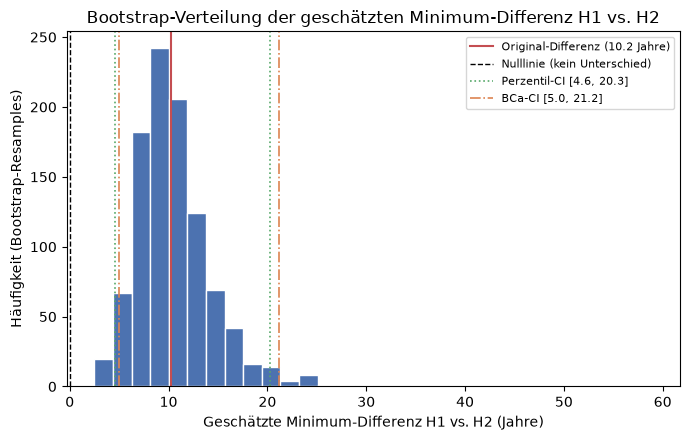

In [59]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(diff_boot, bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(diff_original, color="#C44E52", linewidth=1.5, label=f"Original-Differenz ({diff_original:.1f} Jahre)")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Nulllinie (kein Unterschied)")
ax.axvline(diff_ci_low, color="#55A868", linewidth=1.2, linestyle=":", label=f"Perzentil-CI [{diff_ci_low:.1f}, {diff_ci_high:.1f}]")
ax.axvline(diff_ci_high, color="#55A868", linewidth=1.2, linestyle=":")
ax.axvline(bca_ci_low, color="#DD8452", linewidth=1.2, linestyle="-.", label=f"BCa-CI [{bca_ci_low:.1f}, {bca_ci_high:.1f}]")
ax.axvline(bca_ci_high, color="#DD8452", linewidth=1.2, linestyle="-.")
ax.set_xlabel("Geschätzte Minimum-Differenz H1 vs. H2 (Jahre)")
ax.set_ylabel("Häufigkeit (Bootstrap-Resamples)")
ax.set_title("Bootstrap-Verteilung der geschätzten Minimum-Differenz H1 vs. H2")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "h1_h2_turning_point_bootstrap.png", dpi=150)
plt.show()


**Interpretation:** Das geschätzte Minimum der Alterskurve von H1 liegt bei rund 47 Jahren, jenes von H2 bei rund 37 Jahren. Die geschätzte Differenz beträgt damit rund 10,2 Jahre. Das 95%-Perzentil-Konfidenzintervall für diese Differenz reicht von rund 4,6 bis 20,3 Jahren und schliesst null nicht ein. Dies liefert statistische Evidenz dafür, dass sich die Positionen der geschätzten Minima unterscheiden. Daraus lässt sich jedoch weder ableiten, wie stark die jeweiligen Alterszusammenhänge ausgeprägt sind, noch, dass beide Alterskurven gleich deutlich U-förmig verlaufen. Der Vergleich betrifft ausschliesslich die Lage der geschätzten Minima. Das ergänzend berechnete BCa-Konfidenzintervall wird aufgrund der nicht gesondert validierten gruppierten Jackknife-Approximation lediglich zu Dokumentationszwecken ausgewiesen und nicht zur zusätzlichen Absicherung des Befunds herangezogen.

**Limitation:** Das geschätzte Minimum ist als Quotient aus linearem und quadratischem Alterskoeffizienten definiert. Da insbesondere der quadratische Term in H1 klein ist und mit Schätzunsicherheit behaftet ist, kann das geschätzte Minimum empfindlich auf Schwankungen des Nenners reagieren. Dies ist mit dem Fieller Problem bei Quotienten aus geschätzten Grössen verwandt und zeigt sich in der rechtsschiefen Bootstrap Verteilung der Minimum Differenz mit vereinzelten Ausreissern. Ergänzend zum Perzentil Konfidenzintervall wird daher ein BCa Konfidenzintervall berichtet, das Verzerrung und Asymmetrie der Bootstrap Verteilung berücksichtigt.


In [60]:
bootstrap_summary.to_csv(RESULTS_DIR / "h1_h2_turning_point_bootstrap.csv", index=False)
RESULTS_DIR / "h1_h2_turning_point_bootstrap.csv"

PosixPath('/Users/laraeibel/Desktop/Bachelorarbeit_Python/results/h1_h2_turning_point_bootstrap.csv')



# Robustheitscheck: Alterseffekt nach Produktkategorie


Ziel dieses Abschnitts ist es zu prüfen, ob der Alterseffekt auf Sentiment (H1) und Rating (H2) über die Produktkategorien `Division Name`, `Department Name` und `Class Name` hinweg konsistent ist oder sich nur in bestimmten Kategorien zeigt. Die Analyse erfolgt separat für jede Kategorieausprägung und ohne Interaktionsterme im Gesamtmodell.

**Mindestfallzahl:** Ausprägungen mit weniger als N = 500 Beobachtungen werden zur Sammelkategorie `Sonstige` zusammengefasst. Erreicht auch `Sonstige` die Mindestfallzahl, wird ebenfalls ein Modell geschätzt. Andernfalls erfolgt lediglich eine deskriptive Auswertung mit Mittelwert von `VADER Compound` und N, ohne Modellschätzung.

**Vorgehen:** Für jede Kategorisierung wird getrennt nach Ausprägung das jeweilige Basismodell geschätzt (H1: `VADER Compound ~ Age_c + Age_c_sq`, OLS; H2: `Rating ~ Age_c + Age_c_sq`, `OrderedModel`). Weitere Kontrollvariablen werden nicht aufgenommen, um den Alterseffekt innerhalb der jeweiligen Kategorieausprägung einheitlich und isoliert zu untersuchen. Die zentrierten Altersvariablen `Age_c` und `Age_c_sq` werden unverändert aus dem Gesamtdatensatz übernommen, mit demselben `age_mean` wie im restlichen Notebook. Dadurch bleiben die geschätzten Minima zwischen den Kategorien und mit den bisherigen Gesamtmodellen vergleichbar.

 **Limitation vorab:** Wie im Bootstrap Abschnitt oben gezeigt, ist das geschätzte Minimum ein Quotient aus linearem und quadratischem Alterskoeffizienten und reagiert empfindlich auf einen kleinen oder unsicher geschätzten Nenner (`age_c_sq`). Bei kleineren Kategorie Stichproben kann sich dieses Problem zusätzlich verstärken. Geschätzte Minima ausserhalb des beobachteten Altersbereichs von 18 bis 99 Jahren werden daher als nicht plausibel gekennzeichnet und in den Abbildungen nicht dargestellt, bleiben jedoch zur Transparenz in den CSV Exporten enthalten.


In [61]:
AGE_MIN, AGE_MAX = df["Age"].min(), df["Age"].max()
MIN_N_CATEGORY = 500

tp_h1_basis_ref = turning_point(h1_basis.params["age_c"], h1_basis.params["age_c_sq"])
tp_h2_basis_ref = tp_basis

print(f"Referenz-Minima (Basismodell, Gesamtdatensatz): H1 = {tp_h1_basis_ref:.2f} Jahre, H2 = {tp_h2_basis_ref:.2f} Jahre")
print(f"Beobachteter Altersbereich: {AGE_MIN:.0f} bis {AGE_MAX:.0f} Jahre")


def fit_h1_h2_by_category(source_df, category_col, min_n=MIN_N_CATEGORY):
    """Schaetzt H1- und H2-Basismodell (nur age_c + age_c_sq) getrennt je Auspraegung von
    category_col. Auspraegungen mit weniger als min_n Beobachtungen werden zu 'Sonstige'
    zusammengefasst; erreicht auch 'Sonstige' nicht min_n, wird nur deskriptiv berichtet."""
    cols = {
        category_col: "kategorie_raw",
        "Age_c": "age_c",
        "Age_c_sq": "age_c_sq",
        "VADER Compound": "vader_compound",
        "Rating": "rating",
    }
    sub = source_df.dropna(subset=list(cols.keys())).rename(columns=cols).copy()

    counts = sub["kategorie_raw"].value_counts()
    small = counts[counts < min_n].index.tolist()
    sub["kategorie"] = sub["kategorie_raw"].where(~sub["kategorie_raw"].isin(small), "Sonstige")

    rows = []
    for kat, group in sub.groupby("kategorie", observed=True):
        n = len(group)
        row = {"Kategorie": kat, "N": n, "VADER Compound (Mittelwert)": group["vader_compound"].mean()}
        if n >= min_n:
            res1 = smf.ols("vader_compound ~ age_c + age_c_sq", data=group).fit()
            tp1 = turning_point(res1.params["age_c"], res1.params["age_c_sq"])
            row["Geschätztes Minimum H1"] = tp1
            row["p (age_c, H1)"] = res1.pvalues["age_c"]
            row["Signifikanz age_c H1"] = "ja" if res1.pvalues["age_c"] < 0.05 else "nein"
            row["p (age_c_sq, H1)"] = res1.pvalues["age_c_sq"]
            row["Signifikanz age_c_sq H1"] = "ja" if res1.pvalues["age_c_sq"] < 0.05 else "nein"
            row["Geschätztes Minimum H1 im Altersbereich"] = "ja" if AGE_MIN <= tp1 <= AGE_MAX else "nein"

            try:
                X2 = group[["age_c", "age_c_sq"]].astype(float).rename(columns={"age_c": "Age_c", "age_c_sq": "Age_c_sq"})
                y2 = pd.Categorical(group["rating"], categories=RATING_CATEGORIES, ordered=True)
                res2 = OrderedModel(y2, X2, distr="logit").fit(method="bfgs", disp=False, maxiter=200)
                tp2 = turning_point(res2.params["Age_c"], res2.params["Age_c_sq"])
                row["Geschätztes Minimum H2"] = tp2
                row["p (age_c, H2)"] = res2.pvalues["Age_c"]
                row["Signifikanz age_c H2"] = "ja" if res2.pvalues["Age_c"] < 0.05 else "nein"
                row["p (age_c_sq, H2)"] = res2.pvalues["Age_c_sq"]
                row["Signifikanz age_c_sq H2"] = "ja" if res2.pvalues["Age_c_sq"] < 0.05 else "nein"
                row["Geschätztes Minimum H2 im Altersbereich"] = "ja" if AGE_MIN <= tp2 <= AGE_MAX else "nein"
                row["H2 konvergiert"] = res2.mle_retvals.get("converged")
            except Exception as e:
                row["H2 Fehler"] = str(e)
        else:
            row["Hinweis"] = f"N < {min_n}, nur deskriptiv (kein Modellfit)"
        rows.append(row)

    return pd.DataFrame(rows).sort_values("N", ascending=False).reset_index(drop=True)


def plot_category_turning_points(result_df, title, save_path, tp_h1_ref, tp_h2_ref):
    """Forest-Plot-ähnliche Darstellung: Geschätztes Minimum je Kategorie fuer H1 (Kreis) und H2
    (Quadrat). Gefüllte Marker = age_c signifikant, offene Marker = age_c nicht signifikant.
    Geschätzte Minima ausserhalb des beobachteten Altersbereichs werden nicht geplottet, sondern
    als Text vermerkt und als Liste zurueckgegeben."""
    h2_col = result_df["Geschätztes Minimum H2"] if "Geschätztes Minimum H2" in result_df else pd.Series(dtype=float)
    plot_df = result_df[result_df["Geschätztes Minimum H1"].notna() | h2_col.notna()].copy()
    plot_df = plot_df.sort_values("N")

    fig, ax = plt.subplots(figsize=(7.5, max(2.5, 0.55 * len(plot_df) + 1.2)))
    ax.axvspan(AGE_MIN, AGE_MAX, color="grey", alpha=0.06, zorder=0)

    excluded = []
    for i, (_, row) in enumerate(plot_df.iterrows()):
        tp1 = row.get("Geschätztes Minimum H1")
        tp2 = row.get("Geschätztes Minimum H2")
        h1_sig = row.get("Signifikanz age_c H1") == "ja"
        h2_sig = row.get("Signifikanz age_c H2") == "ja"

        if pd.notna(tp1) and AGE_MIN <= tp1 <= AGE_MAX:
            ax.scatter(tp1, i - 0.14, marker="o", s=80 if h1_sig else 45,
                       facecolors="#4C72B0" if h1_sig else "none", edgecolors="#4C72B0",
                       linewidths=1.4, zorder=3)
        elif pd.notna(tp1):
            excluded.append(f"{row['Kategorie']} (H1: {tp1:.1f} Jahre)")

        if pd.notna(tp2) and AGE_MIN <= tp2 <= AGE_MAX:
            ax.scatter(tp2, i + 0.14, marker="s", s=80 if h2_sig else 45,
                       facecolors="#DD8452" if h2_sig else "none", edgecolors="#DD8452",
                       linewidths=1.4, zorder=3)
        elif pd.notna(tp2):
            excluded.append(f"{row['Kategorie']} (H2: {tp2:.1f} Jahre)")

    ax.axvline(tp_h1_ref, color="#4C72B0", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"H1 Basismodell (Gesamtdatensatz) ({tp_h1_ref:.1f} Jahre)")
    ax.axvline(tp_h2_ref, color="#DD8452", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"H2 Basismodell (Gesamtdatensatz) ({tp_h2_ref:.1f} Jahre)")

    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels([f"{row['Kategorie']} (N={row['N']})" for _, row in plot_df.iterrows()])
    ax.set_xlim(AGE_MIN - 5, AGE_MAX + 5)
    ax.set_xlabel("Geschätztes Minimum (Jahre)")
    ax.set_title(title)

    marker_handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C72B0", markeredgecolor="#4C72B0", markersize=9, label="H1, age_c signifikant"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="none", markeredgecolor="#4C72B0", markersize=9, label="H1, age_c nicht signifikant"),
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#DD8452", markeredgecolor="#DD8452", markersize=9, label="H2, age_c signifikant"),
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="none", markeredgecolor="#DD8452", markersize=9, label="H2, age_c nicht signifikant"),
    ]
    ref_handles, ref_labels = ax.get_legend_handles_labels()
    ax.legend(handles=marker_handles + ref_handles, fontsize=7, loc="best")

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()

    if excluded:
        print("Nicht dargestellt, da ausserhalb des beobachteten Altersbereichs "
              f"({AGE_MIN:.0f} bis {AGE_MAX:.0f} Jahre): " + "; ".join(excluded))
    return excluded


Referenz-Minima (Basismodell, Gesamtdatensatz): H1 = 47.33 Jahre, H2 = 37.39 Jahre
Beobachteter Altersbereich: 18 bis 99 Jahre


## Division Name


In [62]:
result_division = fit_h1_h2_by_category(df, "Division Name")
result_division.to_csv(RESULTS_DIR / "h1_h2_kategorien_robustheit_division.csv", index=False)
result_division


,Kategorie,N,VADER Compound (Mittelwert),Geschätztes Minimum H1,"p (age_c, H1)",Signifikanz age_c H1,"p (age_c_sq, H1)",Signifikanz age_c_sq H1,Geschätztes Minimum H1 im Altersbereich,Geschätztes Minimum H2,"p (age_c, H2)",Signifikanz age_c H2,"p (age_c_sq, H2)",Signifikanz age_c_sq H2,Geschätztes Minimum H2 im Altersbereich,H2 konvergiert
0,General,13364,0.738492,49.608252,0.117386,nein,0.035446,ja,ja,37.990320,0.009902,ja,0.000079,ja,ja,True
1,General Petite,7837,0.745749,43.501126,0.952998,nein,0.027288,ja,ja,32.981597,0.002593,ja,0.019765,ja,ja,True
2,Initmates,1426,0.730549,68.657519,0.377521,nein,0.760681,nein,ja,44.305146,0.877960,nein,0.201464,nein,ja,True


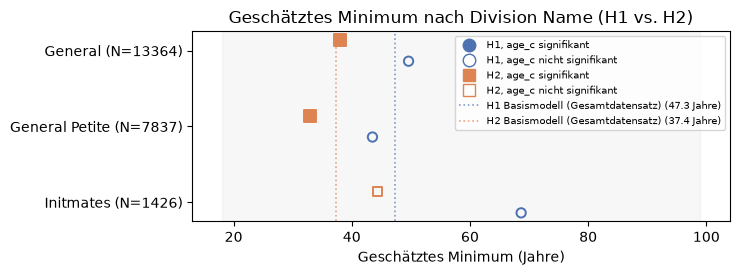

In [63]:
excluded_division = plot_category_turning_points(
    result_division,
    "Geschätztes Minimum nach Division Name (H1 vs. H2)",
    FIGURES_DIR / "h1_h2_kategorien_division.png",
    tp_h1_basis_ref, tp_h2_basis_ref,
)


## Department Name


In [64]:
result_department = fit_h1_h2_by_category(df, "Department Name")
result_department.to_csv(RESULTS_DIR / "h1_h2_kategorien_robustheit_department.csv", index=False)
result_department


,Kategorie,N,VADER Compound (Mittelwert),Geschätztes Minimum H1,"p (age_c, H1)",Signifikanz age_c H1,"p (age_c_sq, H1)",Signifikanz age_c_sq H1,Geschätztes Minimum H1 im Altersbereich,Geschätztes Minimum H2,"p (age_c, H2)",Signifikanz age_c H2,"p (age_c_sq, H2)",Signifikanz age_c_sq H2,Geschätztes Minimum H2 im Altersbereich,H2 konvergiert,Hinweis
0,Tops,10048,0.739959,46.369002,0.272800,nein,0.002466,ja,ja,36.927978,0.001740,ja,0.000063,ja,ja,True,NaN
1,Dresses,6145,0.739337,40.217742,0.762686,nein,0.408453,nein,ja,38.391211,0.210245,nein,0.039035,ja,ja,True,NaN
2,Bottoms,3661,0.751239,51.187670,0.309245,nein,0.299228,nein,ja,20.346004,0.092454,nein,0.566883,nein,ja,True,NaN
3,Intimate,1653,0.731338,55.800090,0.359732,nein,0.515081,nein,ja,43.659587,0.944559,nein,0.115328,nein,ja,True,NaN
4,Jackets,1002,0.741956,69.232729,0.256856,nein,0.712652,nein,ja,37.613189,0.357169,nein,0.186777,nein,ja,True,NaN
5,Sonstige,118,0.630832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"N < 500, nur deskriptiv (kein Modellfit)"


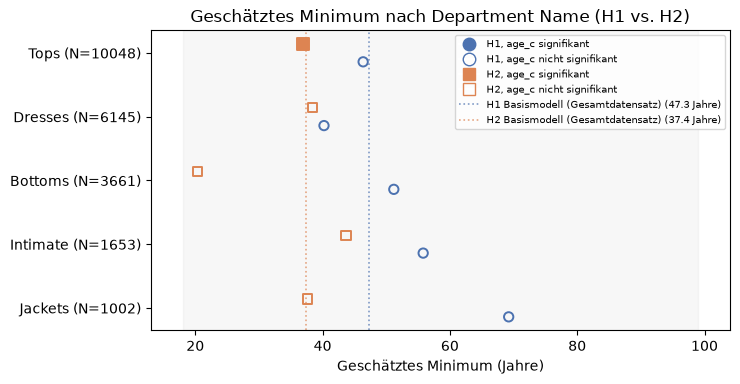

In [65]:
excluded_department = plot_category_turning_points(
    result_department,
    "Geschätztes Minimum nach Department Name (H1 vs. H2)",
    FIGURES_DIR / "h1_h2_kategorien_department.png",
    tp_h1_basis_ref, tp_h2_basis_ref,
)


## Class Name


In [66]:
result_class = fit_h1_h2_by_category(df, "Class Name")
result_class.to_csv(RESULTS_DIR / "h1_h2_kategorien_robustheit_class.csv", index=False)
result_class


,Kategorie,N,VADER Compound (Mittelwert),Geschätztes Minimum H1,"p (age_c, H1)",Signifikanz age_c H1,"p (age_c_sq, H1)",Signifikanz age_c_sq H1,Geschätztes Minimum H1 im Altersbereich,Geschätztes Minimum H2,"p (age_c, H2)",Signifikanz age_c H2,"p (age_c_sq, H2)",Signifikanz age_c_sq H2,Geschätztes Minimum H2 im Altersbereich,H2 konvergiert
0,Dresses,6145,0.739337,40.217742,0.762686,nein,0.408453,nein,ja,38.391211,0.210245,nein,0.039035,ja,ja,True
1,Knits,4626,0.741629,47.736212,0.504663,nein,0.214734,nein,ja,39.934092,0.128389,nein,0.000371,ja,ja,True
2,Blouses,2983,0.752932,2108.254499,0.642352,nein,0.998562,nein,nein,112.250243,0.000923,ja,0.711822,nein,nein,True
3,Sonstige,1726,0.726884,35.602105,0.456637,nein,0.397788,nein,ja,45.113069,0.622890,nein,0.024569,ja,ja,True
4,Sweaters,1380,0.713748,44.727460,0.710245,nein,0.011875,ja,ja,43.443458,0.962128,nein,0.007665,ja,ja,True
5,Pants,1350,0.749371,54.870911,0.654595,nein,0.746860,nein,ja,39.690037,0.566596,nein,0.198919,nein,ja,True
6,Jeans,1103,0.755904,48.478630,0.116047,nein,0.011547,ja,ja,-29.761250,0.070467,nein,0.850698,nein,nein,True
7,Fine gauge,1059,0.730283,45.193104,0.525161,nein,0.002858,ja,ja,41.101593,0.588813,nein,0.034409,ja,ja,True
8,Skirts,903,0.754786,56.816782,0.771520,nein,0.868650,nein,ja,27.540617,0.695615,nein,0.848283,nein,ja,True
9,Jackets,683,0.744348,59.616895,0.694363,nein,0.849848,nein,ja,40.306245,0.651736,nein,0.250066,nein,ja,True


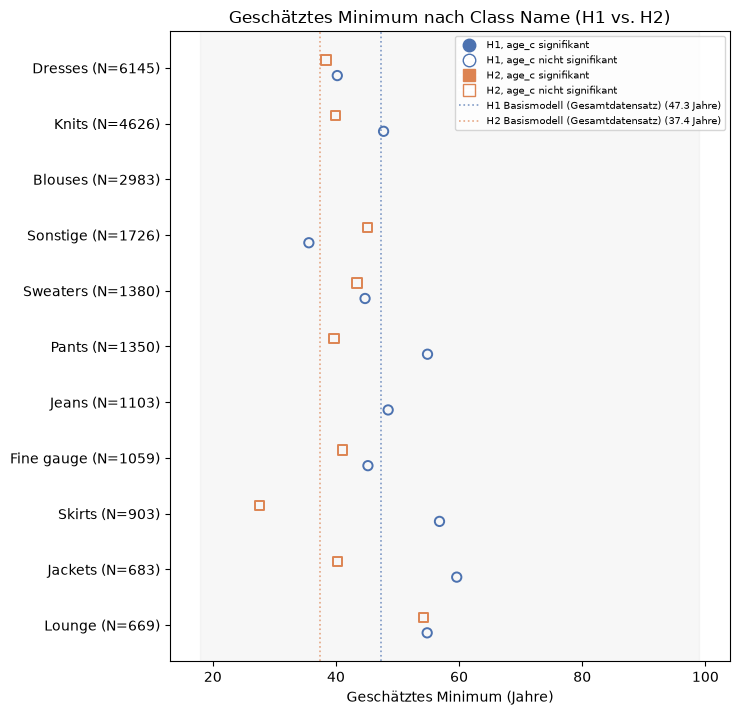

Nicht dargestellt, da ausserhalb des beobachteten Altersbereichs (18 bis 99 Jahre): Jeans (H2: -29.8 Jahre); Blouses (H1: 2108.3 Jahre); Blouses (H2: 112.3 Jahre)


In [67]:
excluded_class = plot_category_turning_points(
    result_class,
    "Geschätztes Minimum nach Class Name (H1 vs. H2)",
    FIGURES_DIR / "h1_h2_kategorien_class.png",
    tp_h1_basis_ref, tp_h2_basis_ref,
)


### Zusammenfassende Interpretation

**Division Name (3 von 3 Kategorien geschätzt):** `General` und `General Petite` zeigen für H1 und H2 ähnliche und plausible geschätzte Minima (H1: 43 bis 50 Jahre; H2: 33 bis 38 Jahre), die nahe an den Referenzwerten des Basismodells für den Gesamtdatensatz liegen (H1: 47,3 Jahre; H2: 37,4 Jahre). `Initmates` als kleinste Division (N = 1'426) weicht mit höheren geschätzten Minima ab (H1: 68,7 Jahre; H2: 44,3 Jahre). Allerdings sind dort weder `age_c` noch `age_c_sq` in einem der beiden Modelle statistisch signifikant. Die Abweichung ist daher statistisch nicht abgesichert und sollte nicht als belastbarer inhaltlicher Unterschied interpretiert werden.

**Department Name (5 von 6 Kategorien geschätzt, `Trend` mit N = 118 nur deskriptiv):** `Trend` fällt bereits deskriptiv auf. Der Mittelwert von `VADER Compound` beträgt 0,63, während die übrigen Departments Werte zwischen 0,73 und 0,75 aufweisen. Aufgrund der geringen Fallzahl konnte für `Trend` jedoch kein separates Modell geschätzt werden. Unter den geschätzten Departments ist bei H1 lediglich für `Tops`, das mit N = 10'048 die grösste Kategorie darstellt, der quadratische Altersterm statistisch signifikant. Bei H2 ist der lineare Altersterm ebenfalls nur für `Tops` signifikant; zusätzlich zeigt sich für `Dresses` (N = 6'145, zweitgrösstes Department) ein signifikanter quadratischer Altersterm (p = 0,039), wenn auch nur knapp unterhalb des Signifikanzniveaus. Bei den übrigen, kleineren Departments (`Bottoms`, `Intimate`, `Jackets`) ist hingegen keiner der beiden Alterskoeffizienten statistisch signifikant. Die dort geschätzten Minima von 51 bis 69 Jahren bei H1 beziehungsweise 20 bis 44 Jahren bei H2 sind daher nur eingeschränkt interpretierbar

**Class Name (11 von 11 Kategorien geschätzt, einschliesslich der Sammelkategorie `Sonstige` mit N = 1'726):** Die meisten Klassen weisen geschätzte Minima in einem plausiblen Bereich auf. Zwei Fälle verdeutlichen jedoch die eingangs beschriebene Limitation besonders deutlich. Bei `Blouses` liegt `age_c_sq` in H1 praktisch bei null und ist statistisch nicht signifikant (p = 0,999). Das daraus berechnete geschätzte Minimum von rund 2'108 Jahren ist daher ein numerisches Artefakt ohne inhaltliche Bedeutung. Bei `Jeans` führt ein ebenfalls unsicher geschätztes `age_c_sq` in H2 zu einem negativen und damit unplausiblen geschätzten Minimum von rund minus 30 Jahren. Beide Werte wurden automatisch als ausserhalb des beobachteten Altersbereichs erkannt und in der Abbildung nicht dargestellt, bleiben jedoch zur Transparenz im CSV Export enthalten. Auch `Blouses` bei H2 fällt mit einem geschätzten Minimum von rund 112 Jahren in diese Kategorie. Obwohl `age_c` dort nominell signifikant ist, ist `age_c_sq` nicht signifikant (p = 0,712), sodass keine statistisch abgesicherte Krümmung vorliegt.

**Gesamtfazit:** Der Alterseffekt ist über die Produktkategorien hinweg nicht durchgängig statistisch nachweisbar. In den meisten einzelnen Kategorien können weder `age_c` noch `age_c_sq` statistisch signifikant von null unterschieden werden. Dies ist mit dem insgesamt schwach ausgeprägten Alterseffekt, insbesondere im H1 Hauptmodell ohne `Recommended IND`, vereinbar. Deutlich abweichende geschätzte Minima sind entweder statistisch nicht abgesichert, wie bei `Initmates` und den meisten Departments, oder entstehen durch einen nahe null und unsicher geschätzten quadratischen Altersterm, wie bei `Blouses` und `Jeans`. Diese Fälle verdeutlichen die bereits im Bootstrap Abschnitt diskutierte Problematik bei der Schätzung des Minimums als Quotient zweier geschätzter Koeffizienten. Die grundsätzliche Tendenz eines höheren geschätzten Minimums bei H1 als bei H2 zeigt sich auch auf Kategorieebene, sollte aufgrund der überwiegend fehlenden statistischen Absicherung jedoch nicht als stabiler kategorieübergreifender Befund interpretiert werden.


## Ergebnistabelle & Speichern

In [68]:
h3_ordinal_coef_rows = params_table(res_h3, "OrderedModel: Rating ~ VADER Compound")
h3_ordinal_summary_rows = [
    {"Modelltyp": "OrderedModel: Rating ~ VADER Compound", "Term": t, "Koeffizient": v}
    for t, v in [
        ("McFadden Pseudo-R2", res_h3.prsquared),
        ("AIC", res_h3.aic),
        ("N", res_h3.nobs),
    ]
]

h3_brant_rows = brant_h3.rename(columns={"Modell": "Modelltyp"})
h3_brant_rows = h3_brant_rows.assign(Term=h3_brant_rows["Test"] + " – " + h3_brant_rows["Variable"])[
    ["Modelltyp", "Term", "Statistik", "df", "p_Wert"]
].rename(columns={"Statistik": "Koeffizient"})

h3_corr_rows = h3_correlations.rename(columns={"Methode": "Modelltyp", "Koeffizient": "Koeffizient"})
h3_corr_rows = h3_corr_rows.assign(Modelltyp="Korrelation Sentiment/Rating: " + h3_corr_rows["Modelltyp"], Term="Korrelationskoeffizient")
h3_corr_rows = h3_corr_rows[["Modelltyp", "Term", "Koeffizient", "p_Wert"]]

h3_results = pd.concat([
    h3_ordinal_coef_rows,
    pd.DataFrame(h3_ordinal_summary_rows),
    h3_brant_rows,
    h3_corr_rows,
], ignore_index=True)

h3_results.to_csv(RESULTS_DIR / "h3_sentiment_rating.csv", index=False)
h3_results


,Modelltyp,Term,Koeffizient,SE,Statistik,p_Wert,df
0,OrderedModel: Rating ~ VADER Compound,VADER_Compound,2.400787,0.037222,64.498592,0.000000e+00,NaN
1,OrderedModel: Rating ~ VADER Compound,1/2,-2.028423,0.040172,-50.493572,0.000000e+00,NaN
2,OrderedModel: Rating ~ VADER Compound,2/3,0.276705,0.025109,11.020119,3.056545e-28,NaN
3,OrderedModel: Rating ~ VADER Compound,3/4,0.134537,0.018186,7.397752,1.385092e-13,NaN
4,OrderedModel: Rating ~ VADER Compound,4/5,0.167697,0.013278,12.629612,1.449919e-36,NaN
5,OrderedModel: Rating ~ VADER Compound,McFadden Pseudo-R2,0.082737,NaN,NaN,NaN,NaN
6,OrderedModel: Rating ~ VADER Compound,AIC,50767.013400,NaN,NaN,NaN,NaN
7,OrderedModel: Rating ~ VADER Compound,N,22640.000000,NaN,NaN,NaN,NaN
8,H3: Rating ~ VADER Compound,Brant (Wald) – Omnibus (alle Prädiktoren),123.409342,NaN,NaN,0.000000e+00,3.0
9,H3: Rating ~ VADER Compound,Brant (Wald) – VADER_Compound,123.409342,NaN,NaN,0.000000e+00,3.0
